## Creating Baseline

In [4]:
import pandas as pd
from pathlib import Path

# ==============================
# PATH TO DATASET
# ==============================
input_path = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_dataset.csv"

# ==============================
# LOAD DATA
# ==============================
print("Loading dataset...")
df = pd.read_csv(input_path, usecols=["steamid", "appid"])
print(f"Total rows in original file: {len(df)}")
initial_users = df["steamid"].nunique()
print(f"Unique users in original file: {initial_users}")

# ==============================
# REMOVE DUPLICATES
# ==============================
df = df.drop_duplicates(["steamid", "appid"])

# ==============================
# FILTER USERS WITH ENOUGH GAMES
# ==============================
MIN_GAMES = 5
user_counts = df.groupby("steamid").size()
valid_users = user_counts[user_counts >= MIN_GAMES].index
df = df[df["steamid"].isin(valid_users)]
print(f"Users kept (>= {MIN_GAMES} games): {len(valid_users)}")

# ==============================
# LEAVE-TWO-OUT SPLIT: VALIDATION & TEST
# ==============================
print("Selecting validation and test interactions...")

def leave_two_out(x):
    """Randomly select 1 validation and 1 test per user."""
    steamid = x.name  # the group key
    if len(x) < 2:
        return pd.DataFrame(columns=["steamid", "appid", "split"])
    
    sampled = x.sample(n=2, random_state=None)
    val  = sampled.iloc[0:1].copy()
    test = sampled.iloc[1:2].copy()
    
    val["split"] = "validation"
    test["split"] = "test"
    
    val["steamid"] = steamid
    test["steamid"] = steamid
    
    return pd.concat([val, test])

pairs = df.groupby("steamid", group_keys=False).apply(leave_two_out).reset_index(drop=True)

# ==============================
# EXTRACT VALIDATION & TEST
# ==============================
validation_pairs = pairs[pairs["split"] == "validation"][["steamid", "appid"]]
test_pairs       = pairs[pairs["split"] == "test"][["steamid", "appid"]]

# ==============================
# PRINT SOME INFO
# ==============================
print("\nValidation pairs:")
print(validation_pairs.shape)
print(validation_pairs.head())
print("Unique users in validation:", validation_pairs["steamid"].nunique())

print("\nTest pairs:")
print(test_pairs.shape)
print(test_pairs.head())
print("Unique users in test:", test_pairs["steamid"].nunique())

# ==============================
# SAVE TO NOTEBOOK DIRECTORY
# ==============================
output_val_path = Path.cwd() / "validation_user_game_pairs.csv"
output_test_path = Path.cwd() / "test_user_game_pairs.csv"

validation_pairs.to_csv(output_val_path, index=False)
test_pairs.to_csv(output_test_path, index=False)

print(f"\nSaved validation file to: {output_val_path}")
print(f"Saved test file to: {output_test_path}")

Loading dataset...
Total rows in original file: 4010476
Unique users in original file: 31021
Users kept (>= 5 games): 28211
Selecting validation and test interactions...

Validation pairs:
(28211, 2)
             steamid   appid
0  76561197960266945  569860
2  76561197960269228     240
4  76561197960270968      50
6  76561197960274625   20900
8  76561197960276349     360
Unique users in validation: 28211

Test pairs:
(28211, 2)
             steamid    appid
1  76561197960266945   287120
3  76561197960269228       70
5  76561197960270968   104900
7  76561197960274625    71230
9  76561197960276349  1243220
Unique users in test: 28211

Saved validation file to: C:\Projects\GitHub\bachelor_project\validation_user_game_pairs.csv
Saved test file to: C:\Projects\GitHub\bachelor_project\test_user_game_pairs.csv


In [6]:
import pandas as pd
from pathlib import Path

# ==============================
# PATHS
# ==============================
user_games_path = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\final_data\user_games.csv"
baseline_path = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_dataset.csv"
val_pairs_path = Path.cwd() / "validation_user_game_pairs.csv"
test_pairs_path = Path.cwd() / "test_user_game_pairs.csv"
output_path = Path.cwd() / "baseline_features_train_only.csv"

# ==============================
# LOAD DATA
# ==============================
print("Loading user-game interactions...")
user_games = pd.read_csv(user_games_path)

val_pairs = pd.read_csv(val_pairs_path)
test_pairs = pd.read_csv(test_pairs_path)

# ==============================
# FILTER TRAIN INTERACTIONS
# ==============================
exclude_pairs = pd.concat([val_pairs, test_pairs], ignore_index=True)

user_games = user_games.merge(
    exclude_pairs.assign(exclude=1),
    on=["steamid", "appid"],
    how="left"
)

train_games = user_games[user_games["exclude"].isna()].drop(columns=["exclude"])

print(f"Training interactions remaining: {len(train_games)}")

# ==============================
# LOAD BASELINE
# ==============================
baseline_df = pd.read_csv(baseline_path)

print(f"Baseline rows BEFORE update: {len(baseline_df)}")

# SAVE ORIGINAL COLUMN ORDER
original_columns = baseline_df.columns.tolist()

# ==============================
# REMOVE OLD FEATURES
# ==============================
features_to_replace = [
    "total_games_owned",
    "total_playtime_minutes",
    "median_playtime_minutes",
    "unique_genres_played",
    "user_count",
    "game_total_playtime_minutes",
]

baseline_df = baseline_df.drop(columns=features_to_replace, errors="ignore")

# ==============================
# USER FEATURES (TRAIN ONLY)
# ==============================
print("Computing user features...")

user_features = (
    train_games.groupby("steamid")
    .agg(
        total_games_owned=("appid", "nunique"),
        total_playtime_minutes=("playtime_minutes", "sum"),
        median_playtime_minutes=("playtime_minutes", "median"),
    )
    .reset_index()
)

# ==============================
# GAME FEATURES (TRAIN ONLY)
# ==============================
print("Computing game features...")

game_features = (
    train_games.groupby("appid")
    .agg(
        user_count=("steamid", "nunique"),
        game_total_playtime_minutes=("playtime_minutes", "sum"),
    )
    .reset_index()
)

# ==============================
# MERGE FEATURES
# ==============================
baseline_df = baseline_df.merge(user_features, on="steamid", how="left")
baseline_df = baseline_df.merge(game_features, on="appid", how="left")

# ==============================
# UNIQUE GENRES PLAYED
# ==============================
print("Computing unique genres...")

train_with_genres = train_games.merge(
    baseline_df[["appid", "genres"]].drop_duplicates(),
    on="appid",
    how="left",
)

train_with_genres["genres"] = train_with_genres["genres"].fillna("")
train_with_genres["genres_list"] = train_with_genres["genres"].str.split(";")

user_unique_genres = (
    train_with_genres.explode("genres_list")
    .groupby("steamid")["genres_list"]
    .nunique()
    .rename("unique_genres_played")
    .reset_index()
)

baseline_df = baseline_df.merge(user_unique_genres, on="steamid", how="left")

# ==============================
# RESTORE ORIGINAL COLUMN ORDER
# ==============================
baseline_df = baseline_df[original_columns]

# ==============================
# CHECK RESULTS
# ==============================
print("\nUpdated baseline head:")
print(baseline_df.head())

print(f"\nRows AFTER update: {len(baseline_df)}")

# ==============================
# SAVE
# ==============================
baseline_df.to_csv(output_path, index=False)

print(f"\nSaved file:\n{output_path}")

Loading user-game interactions...
Training interactions remaining: 3954054
Baseline rows BEFORE update: 4010476
Computing user features...
Computing game features...
Computing unique genres...

Updated baseline head:
             steamid  appid country  total_games_owned  \
0  76561198064675174    400      IT                168   
1  76561198064675174    500      IT                168   
2  76561198064675174    550      IT                168   
3  76561198064675174    620      IT                168   
4  76561198064675174   3900      IT                168   

   total_playtime_minutes  median_playtime_minutes  unique_genres_played  \
0                  498693                    588.0                    15   
1                  498693                    588.0                    15   
2                  498693                    588.0                    15   
3                  498693                    588.0                    15   
4                  498693                    588.0    

In [6]:
import pandas as pd
import numpy as np
from pathlib import Path
import time

# ==============================
# PATHS
# ==============================
user_games_path = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\final_data\user_games.csv"
users_path = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\final_data\users.csv"
baseline_path = r"C:\Users\jkgas\OneDrive\Desktop\data_science\Spring_2026\bachelor_project\data\baseline\baseline_dataset.csv"

val_pairs_path = Path.cwd() / "validation_user_game_pairs.csv"
test_pairs_path = Path.cwd() / "test_user_game_pairs.csv"
output_path = Path.cwd() / "baseline_features_playtime_capped.csv"

# ==============================
# LOAD DATA
# ==============================
print("Loading datasets...")
user_games = pd.read_csv(user_games_path)
users = pd.read_csv(users_path)
baseline_df = pd.read_csv(baseline_path)
val_pairs = pd.read_csv(val_pairs_path)
test_pairs = pd.read_csv(test_pairs_path)

original_columns = baseline_df.columns.tolist()

# ==============================
# COMPUTE ACCOUNT AGE
# ==============================
print("Computing account age in minutes...")
NOW_TS = time.time()
users["account_age_minutes"] = (NOW_TS - users["account_created"]) / 60

user_games = user_games.merge(
    users[["steamid", "account_age_minutes"]],
    on="steamid",
    how="left"
)

# ==============================
# CAP INDIVIDUAL PLAYTIME
# ==============================
print("Capping individual playtime by account age...")
global_cap = user_games["playtime_minutes"].quantile(0.999)

user_games["playtime_capped"] = np.where(
    user_games["account_age_minutes"].notna(),
    np.minimum(user_games["playtime_minutes"], user_games["account_age_minutes"]),
    np.minimum(user_games["playtime_minutes"], global_cap)
)

# ==============================
# EXCLUDE TEST/VALIDATION FROM TRAIN
# ==============================
exclude_pairs = pd.concat([val_pairs, test_pairs], ignore_index=True)

user_games = user_games.merge(
    exclude_pairs.assign(exclude=1),
    on=["steamid", "appid"],
    how="left"
)

train_games = user_games[user_games["exclude"].isna()].copy()
print(f"Training interactions remaining: {len(train_games)}")

# ==============================
# REMOVE OLD FEATURES
# ==============================
features_to_replace = [
    "total_games_owned",
    "total_playtime_minutes",
    "median_playtime_minutes",
    "unique_genres_played",
    "user_count",
    "game_total_playtime_minutes",
    "playtime_capped"  # will become user_game_playtime
]
baseline_df = baseline_df.drop(columns=features_to_replace, errors="ignore")

# ==============================
# COMPUTE USER FEATURES
# ==============================
print("Computing user aggregates...")
user_features = (
    train_games.groupby("steamid")
    .agg(
        total_games_owned=("appid", "nunique"),
        total_playtime_minutes=("playtime_capped", "sum"),
        median_playtime_minutes=("playtime_capped", "median"),
    )
    .reset_index()
)

# ==============================
# COMPUTE GAME FEATURES
# ==============================
print("Computing game aggregates...")
game_features = (
    train_games.groupby("appid")
    .agg(
        user_count=("steamid", "nunique"),
        game_total_playtime_minutes=("playtime_capped", "sum"),
    )
    .reset_index()
)

# ==============================
# MERGE FEATURES INTO BASELINE
# ==============================
baseline_df = baseline_df.merge(user_features, on="steamid", how="left")
baseline_df = baseline_df.merge(game_features, on="appid", how="left")

# ==============================
# UNIQUE GENRES
# ==============================
print("Computing unique genres played...")
train_with_genres = train_games.merge(
    baseline_df[["appid", "genres"]].drop_duplicates(),
    on="appid",
    how="left"
)

train_with_genres["genres"] = train_with_genres["genres"].fillna("")
train_with_genres["genres_list"] = train_with_genres["genres"].str.split(";")

user_unique_genres = (
    train_with_genres
    .explode("genres_list")
    .groupby("steamid")["genres_list"]
    .nunique()
    .rename("unique_genres_played")
    .reset_index()
)

baseline_df = baseline_df.merge(user_unique_genres, on="steamid", how="left")

# ==============================
# ADD USER-GAME PLAYTIME FEATURE
# ==============================
print("Adding user_game_playtime feature...")
baseline_df = baseline_df.merge(
    train_games[["steamid", "appid", "playtime_capped"]],
    on=["steamid", "appid"],
    how="left"
)

# Set 0 for test/validation pairs
baseline_df.loc[
    baseline_df[["steamid", "appid"]].apply(tuple, axis=1).isin(
        list(exclude_pairs[["steamid", "appid"]].itertuples(index=False, name=None))
    ),
    "playtime_capped"
] = 0

baseline_df = baseline_df.rename(columns={"playtime_capped": "user_game_playtime"})

# ==============================
# CAP TOTAL_PLAYTIME TO ACCOUNT AGE
# ==============================
baseline_df = baseline_df.merge(
    users[["steamid", "account_age_minutes"]],
    on="steamid",
    how="left"
)

overage_mask = baseline_df["total_playtime_minutes"] > baseline_df["account_age_minutes"]
baseline_df.loc[overage_mask, "total_playtime_minutes"] = baseline_df.loc[overage_mask, "account_age_minutes"]

# ==============================
# RESTORE COLUMN ORDER
# ==============================
cols = original_columns + ["user_game_playtime"]
baseline_df = baseline_df.reindex(columns=cols)

# ==============================
# SANITY CHECKS
# ==============================
print("\nHEAD:")
print(baseline_df.head())
print("\nRows:", len(baseline_df))

# ==============================
# SAVE
# ==============================
baseline_df.to_csv(output_path, index=False)
print(f"\nSaved to:\n{output_path}")

# ==============================
# SANITY CHECKS FOR TIME FEATURES
# ==============================
print("\nSanity checks for time-related features:")

# Sanity checks after capping
print("Playtime stats after capping:")
print(user_games["playtime_capped"].describe())

# Check max capped against account age
over_account_age = (user_games["playtime_capped"] > user_games["account_age_minutes"]).sum()
print(f"Rows where capped playtime > account age: {over_account_age}")

# Check zeros after capping
zeros_after_capping = (user_games["playtime_capped"] == 0).sum()
print(f"Rows with zero playtime after capping: {zeros_after_capping}")

Loading datasets...
Computing account age in minutes...
Capping individual playtime by account age...
Training interactions remaining: 3954054
Computing user aggregates...
Computing game aggregates...
Computing unique genres played...
Adding user_game_playtime feature...

HEAD:
             steamid  appid country  total_games_owned  \
0  76561198064675174    400      IT                168   
1  76561198064675174    500      IT                168   
2  76561198064675174    550      IT                168   
3  76561198064675174    620      IT                168   
4  76561198064675174   3900      IT                168   

   total_playtime_minutes  median_playtime_minutes  unique_genres_played  \
0                498693.0                    588.0                    15   
1                498693.0                    588.0                    15   
2                498693.0                    588.0                    15   
3                498693.0                    588.0                  

In [5]:
# Count how many playtimes are exactly 0 in the original user_games
num_zero_playtime = (user_games["playtime_minutes"] == 0).sum()
total_rows = len(user_games)
print(f"User-game pairs with 0 playtime: {num_zero_playtime} / {total_rows} "
      f"({num_zero_playtime / total_rows:.2%})")

User-game pairs with 0 playtime: 1801354 / 4010476 (44.92%)


In [5]:
# Original list of 59 genres
genres = ['Acción', 'Accounting', 'Actie', 'Action', 'Adventure', 'Akcja', 'Aksiyon', 'Akční',
          'Animation & Modeling', 'Audio Production', 'Aventura', 'Avontuur', 'Casual',
          'Design & Illustration', 'Documentary', 'Early Access', 'Education', 'Episodic',
          'Free To Play', 'Game Development', 'Gore', 'Indie', 'Indépendant', 'Macera',
          'Massively Multiplayer', 'Movie', 'Nudity', 'Occasionnel', 'Photo Editing', 'RPG',
          'RYO', 'Racing', 'Rol', 'Sexual Content', 'Simuladores', 'Simulation',
          'Software Training', 'Sport', 'Sports', 'Strategie', 'Strategy', 'Symulacje',
          'Tutorial', 'Utilities', 'Video Production', 'Violent', 'Web Publishing',
          'Бесплатные', 'Инди', 'Казуальные игры', 'Приключенческие игры', 'Ролевые игры',
          'Симуляторы', 'Стратегии', 'Экшены', '冒险', '動作', '独立', '角色扮演']

# Define the new grouped categories
genre_groups = {
    "Action": ['Action', 'Acción', 'Akcja', 'Aksiyon', 'Actie', 'Akční', 'Экшены', '動作'],
    "Adventure": ['Adventure', 'Aventura', 'Avontuur', '冒险', 'Приключенческие игры', 'Macera'],
    "RPG": ['RPG', 'RYO', 'Ролевые игры', '角色扮演'],
    "Casual": ['Casual', 'Occasionnel', 'Казуальные игры'],
    "Indie": ['Indie', 'Indépendant', '独立', 'Инди'],
    "Racing": ['Racing', 'Rol'],
    "Simulation": ['Simulation', 'Simuladores', 'Symulacje', 'Симуляторы'],
    "Strategy": ['Strategy', 'Strategie', 'Стратегии'],
    "Sports": ['Sport', 'Sports'],
    "Violent": ['Gore', 'Violent'],
    "Adult": ['Nudity', 'Sexual Content'],
    "Non-gameplay/Tools": ['Education', 'Documentary', 'Movie', 'Tutorial', 'Accounting', 'Audio Production', 'Video Production',
                           'Photo Editing', 'Design & Illustration', 'Web Publishing', 'Utilities', 'Software Training', 'Game Development', 'Animation & Modeling'],
    "Other": ['Early Access', 'Episodic', 'Free To Play', 'Massively Multiplayer', 'Бесплатные']
}

# Print nicely
for group, items in genre_groups.items():
    print(f"{group} ({len(items)} genres):")
    print("  " + ", ".join(items))
    print()

Action (8 genres):
  Action, Acción, Akcja, Aksiyon, Actie, Akční, Экшены, 動作

Adventure (6 genres):
  Adventure, Aventura, Avontuur, 冒险, Приключенческие игры, Macera

RPG (4 genres):
  RPG, RYO, Ролевые игры, 角色扮演

Casual (3 genres):
  Casual, Occasionnel, Казуальные игры

Indie (4 genres):
  Indie, Indépendant, 独立, Инди

Racing (2 genres):
  Racing, Rol

Simulation (4 genres):
  Simulation, Simuladores, Symulacje, Симуляторы

Strategy (3 genres):
  Strategy, Strategie, Стратегии

Sports (2 genres):
  Sport, Sports

Violent (2 genres):
  Gore, Violent

Adult (2 genres):
  Nudity, Sexual Content

Non-gameplay/Tools (14 genres):
  Education, Documentary, Movie, Tutorial, Accounting, Audio Production, Video Production, Photo Editing, Design & Illustration, Web Publishing, Utilities, Software Training, Game Development, Animation & Modeling

Other (5 genres):
  Early Access, Episodic, Free To Play, Massively Multiplayer, Бесплатные



In [9]:
import pandas as pd

# CSV path
baseline_path = r"D:\bachelor_project\ml\baseline\baseline_dataset.csv"

# Load CSV, skip bad lines
df = pd.read_csv(
    baseline_path,
    sep=None,        
    engine='python',   
    skipinitialspace=True,
    on_bad_lines='skip'
)

print("Rows loaded:", len(df))
print("Columns:", df.columns.tolist())

# Aggregated genre groups
genre_groups = {
    "Action": ['Action', 'Acción', 'Akcja', 'Aksyon', 'Actie', 'Akční', 'Экшены', '動作'],
    "Adventure": ['Adventure', 'Aventura', 'Avontuur', '冒险', 'Приключенческие игры', 'Macera'],
    "RPG": ['RPG', 'RYO', 'Ролевые игры', '角色扮演'],
    "Casual": ['Casual', 'Occasionnel', 'Казуальные игры'],
    "Indie": ['Indie', 'Indépendant', '独立', 'Инди'],
    "Racing": ['Racing', 'Rol'],
    "Simulation": ['Simulation', 'Simuladores', 'Symulacje', 'Симуляторы'],
    "Strategy": ['Strategy', 'Strategie', 'Стратегии'],
    "Sports": ['Sport', 'Sports'],
    "Violent": ['Gore', 'Violent'],
    "Adult": ['Nudity', 'Sexual Content'],
    "Non-gameplay/Tools": [
        'Education', 'Documentary', 'Movie', 'Tutorial', 'Accounting', 'Audio Production', 
        'Video Production', 'Photo Editing', 'Design & Illustration', 'Web Publishing', 
        'Utilities', 'Software Training', 'Game Development', 'Animation & Modeling'
    ],
    "Other": ['Early Access', 'Episodic', 'Free To Play', 'Massively Multiplayer', 'Бесплатные']
}

# Build reverse map for quick lookup
genre_to_group = {g: group for group, genres in genre_groups.items() for g in genres}

# Initialize counts
counts = {grp: 0 for grp in genre_groups.keys()}

# Count occurrences per row, accounting for multiple genres per game
for genres_str in df['genres']:
    if pd.isna(genres_str):
        continue
    for g in map(str.strip, genres_str.split(';')):
        group = genre_to_group.get(g)
        if group:
            counts[group] += 1

# Convert to DataFrame for nicer printing
counts_df = pd.DataFrame(
    list(counts.items()), columns=["Genre Group", "Count"]
).sort_values(by="Count", ascending=False)

print(counts_df)

Rows loaded: 4010476
Columns: ['steamid', 'appid', 'country', 'total_games_owned', 'total_playtime_minutes', 'median_playtime_minutes', 'unique_genres_played', 'name', 'genres', 'developer', 'publisher', 'platforms', 'release_date', 'user_count', 'game_total_playtime_minutes']
           Genre Group    Count
0               Action  2401617
4                Indie  1943359
1            Adventure  1680702
2                  RPG   859529
3               Casual   792384
7             Strategy   746742
6           Simulation   659679
12               Other   400466
5               Racing   145554
8               Sports   127349
11  Non-gameplay/Tools   103441
9              Violent    17598
10               Adult     4434


In [11]:
import pandas as pd

baseline_path = r"D:\bachelor_project\ml\baseline\baseline_dataset.csv"

# Load CSV safely
df = pd.read_csv(
    baseline_path,
    sep=None,        # auto-detect separator
    engine='python',
    skipinitialspace=True,
    on_bad_lines='skip'
)

# Make sure 'genres' column exists
if 'genres' not in df.columns:
    print("Columns detected:", df.columns.tolist())
    raise KeyError("'genres' column not found!")

# Count number of genres per game
df['num_genres'] = df['genres'].fillna("").apply(lambda x: len(x.split(';')))

# Maximum number of genres
max_genres = df['num_genres'].max()
print("Maximum number of genres for a single game:", max_genres)

# Optional: distribution of number of genres
print(df['num_genres'].value_counts().sort_index())

Maximum number of genres for a single game: 13
num_genres
1     1023045
2     1275720
3      941506
4      461900
5      205556
6       87345
7       11814
8        2259
9        1107
10        222
13          2
Name: count, dtype: int64


Maximum number of merged groups per game: 10
Distribution of number of merged groups per game:
num_merged_groups
0       22553
1     1010779
2     1276516
3      972951
4      449515
5      203164
6       62182
7       11180
8        1428
9         145
10         63
Name: count, dtype: int64


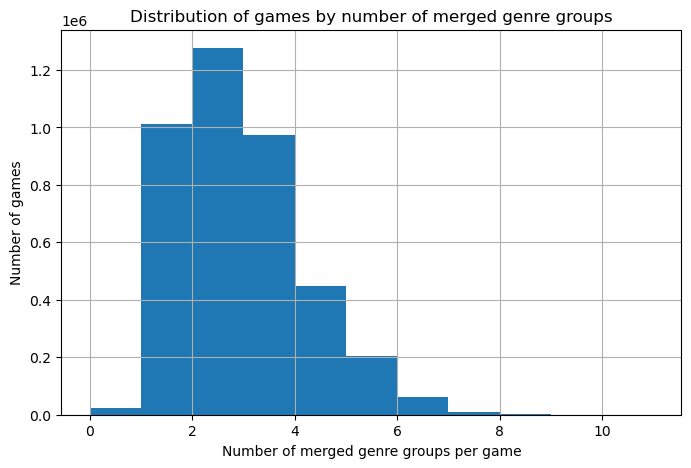

In [12]:
import pandas as pd

baseline_path = r"D:\bachelor_project\ml\baseline\baseline_dataset.csv"

# Load CSV safely
df = pd.read_csv(
    baseline_path,
    sep=None,         # auto-detect separator
    engine='python',
    skipinitialspace=True,
    on_bad_lines='skip'
)

# Define your genre groups
genre_groups = {
    "Action": ['Action', 'Acción', 'Akcja', 'Aksyon', 'Actie', 'Akční', 'Экшены', '動作'],
    "Adventure": ['Adventure', 'Aventura', 'Avontuur', '冒险', 'Приключенческие игры', 'Macera'],
    "RPG": ['RPG', 'RYO', 'Ролевые игры', '角色扮演'],
    "Casual": ['Casual', 'Occasionnel', 'Казуальные игры'],
    "Indie": ['Indie', 'Indépendant', '独立', 'Инди'],
    "Racing": ['Racing', 'Rol'],
    "Simulation": ['Simulation', 'Simuladores', 'Symulacje', 'Симуляторы'],
    "Strategy": ['Strategy', 'Strategie', 'Стратегии'],
    "Sports": ['Sport', 'Sports'],
    "Violent": ['Gore', 'Violent'],
    "Adult": ['Nudity', 'Sexual Content'],
    "Non-gameplay/Tools": [
        'Education', 'Documentary', 'Movie', 'Tutorial', 'Accounting', 'Audio Production', 
        'Video Production', 'Photo Editing', 'Design & Illustration', 'Web Publishing', 
        'Utilities', 'Software Training', 'Game Development', 'Animation & Modeling'
    ],
    "Other": ['Early Access', 'Episodic', 'Free To Play', 'Massively Multiplayer', 'Бесплатные']
}

# Reverse lookup: genre -> group
genre_to_group = {g: grp for grp, genres in genre_groups.items() for g in genres}

# Map original genres to aggregated groups
def map_to_groups(genres_str):
    if pd.isna(genres_str) or genres_str.strip() == "":
        return []
    genres = [g.strip() for g in genres_str.split(";")]
    groups = set()
    for g in genres:
        grp = genre_to_group.get(g)
        if grp:
            groups.add(grp)
    return list(groups)

df['merged_genre_groups'] = df['genres'].apply(map_to_groups)

# Count how many distinct merged groups each game has
df['num_merged_groups'] = df['merged_genre_groups'].apply(len)

# Inspect distribution
print("Maximum number of merged groups per game:", df['num_merged_groups'].max())
print("Distribution of number of merged groups per game:")
print(df['num_merged_groups'].value_counts().sort_index())

# Optional: simple histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
df['num_merged_groups'].hist(bins=range(df['num_merged_groups'].max()+2))
plt.xlabel("Number of merged genre groups per game")
plt.ylabel("Number of games")
plt.title("Distribution of games by number of merged genre groups")
plt.show()

In [13]:
import pandas as pd

# Load CSV with the single-column fix
baseline_path = r"D:\bachelor_project\ml\baseline\baseline_dataset.csv"

# Split the single combined column into proper columns
df = pd.read_csv(baseline_path, sep=",", engine="python")  # first try with comma
if len(df.columns) == 1:
    # maybe the CSV was really semicolon-separated
    df = pd.read_csv(baseline_path, sep=";", engine="python")

# Make sure 'genres' column exists
print("Columns loaded:", df.columns.tolist())

# Count missing or empty genres
missing_genre_count = df['genres'].isna().sum()  # NaN
empty_genre_count = (df['genres'].astype(str).str.strip() == '').sum()  # empty string

total_missing = missing_genre_count + empty_genre_count
print(f"Games with missing genre: {total_missing}")

Columns loaded: ['steamid', 'appid', 'country', 'total_games_owned', 'total_playtime_minutes', 'median_playtime_minutes', 'unique_genres_played', 'name', 'genres', 'developer', 'publisher', 'platforms', 'release_date', 'user_count', 'game_total_playtime_minutes', 'user_game_playtime']
Games with missing genre: 21143


## Splits

In [3]:
import pandas as pd

# Paths to your CSV files
files = {
    "train": r"D:\bachelor_project\ml\sets\train.csv",
    "val": r"D:\bachelor_project\ml\sets\val.csv",
    "test": r"D:\bachelor_project\ml\sets\test.csv"
}

# Loop through each file
for name, path in files.items():
    print(f"\n=== {name.upper()} FILE ===")
    
    # Print first 10 rows
    try:
        df_head = pd.read_csv(path, sep=";", nrows=10)  # adjust sep if needed
        print("First 10 rows:")
        print(df_head)
    except Exception as e:
        print(f"Error reading first 10 rows: {e}")
    
    # Count total rows without loading whole file
    try:
        with open(path, "r", encoding="utf-8") as f:
            total_rows = sum(1 for line in f) - 1  # subtract 1 for header
        print(f"Total rows: {total_rows}")
    except Exception as e:
        print(f"Error counting rows: {e}")


=== TRAIN FILE ===
First 10 rows:
             steamid  appid country  total_games_owned  \
0  76561198064675174    400      IT                168   
1  76561198064675174    500      IT                168   
2  76561198064675174    550      IT                168   
3  76561198064675174    620      IT                168   
4  76561198064675174   3900      IT                168   
5  76561198064675174   3910      IT                168   
6  76561198064675174   7650      IT                168   
7  76561198064675174   7660      IT                168   
8  76561198064675174   7670      IT                168   
9  76561198064675174   7730      IT                168   

   total_playtime_minutes  median_playtime_minutes  unique_genres_played  \
0                498693.0                    588.0                    15   
1                498693.0                    588.0                    15   
2                498693.0                    588.0                    15   
3                49869

In [22]:
import pandas as pd
import random

# Paths to original files
files = {
    "train": r"D:\bachelor_project\ml\sets\train.csv",
    "val": r"D:\bachelor_project\ml\sets\val.csv",
    "test": r"D:\bachelor_project\ml\sets\test.csv"
}

# Paths to save sampled files
output_files = {
    "train": r"D:\bachelor_project\ml\sets\train_sample.csv",
    "val": r"D:\bachelor_project\ml\sets\val_sample.csv",
    "test": r"D:\bachelor_project\ml\sets\test_sample.csv"
}

# Set random seed for reproducibility
RANDOM_SEED = 42
random.seed(RANDOM_SEED)

# Step 1: Get unique steamids from each file (memory-efficient)
def get_unique_users(file_path, chunksize=10**6):
    users = set()
    for chunk in pd.read_csv(file_path, sep=";", usecols=["steamid"], chunksize=chunksize):
        users.update(chunk["steamid"].unique())
    return users

train_users = get_unique_users(files["train"])
val_users = get_unique_users(files["val"])
test_users = get_unique_users(files["test"])

# Step 2: Find users that exist in all three files
common_users = train_users & val_users & test_users
print(f"Total common users in all three files: {len(common_users)}")

if len(common_users) < 100:
    raise ValueError("Not enough users exist in all three files to sample 100.")

# Step 3: Randomly sample 100 users from common users
sample_users = random.sample(list(common_users), 100)
print(f"Selected {len(sample_users)} users for sampling (seed={RANDOM_SEED}).")

# Step 4: Function to filter by sampled users and save new CSV
def sample_file(input_path, output_path, users_set):
    chunksize = 10**6
    first_chunk = True
    for chunk in pd.read_csv(input_path, sep=";", chunksize=chunksize):
        chunk_filtered = chunk[chunk["steamid"].isin(users_set)]
        if first_chunk:
            chunk_filtered.to_csv(output_path, sep=";", index=False)
            first_chunk = False
        else:
            chunk_filtered.to_csv(output_path, sep=";", index=False, mode="a", header=False)

# Step 5: Apply for all three files
for key in files:
    sample_file(files[key], output_files[key], set(sample_users))

print("Sampling complete. New small CSV files created with exactly the same 100 users in train, val, and test.")

Total common users in all three files: 28211
Selected 100 users for sampling (seed=42).


C:\Users\jkgas\AppData\Local\Temp\ipykernel_9180\3031019638.py:48: DtypeWarning: Columns (0: country) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(input_path, sep=";", chunksize=chunksize):
C:\Users\jkgas\AppData\Local\Temp\ipykernel_9180\3031019638.py:48: DtypeWarning: Columns (0: country) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(input_path, sep=";", chunksize=chunksize):
C:\Users\jkgas\AppData\Local\Temp\ipykernel_9180\3031019638.py:48: DtypeWarning: Columns (0: country) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(input_path, sep=";", chunksize=chunksize):
C:\Users\jkgas\AppData\Local\Temp\ipykernel_9180\3031019638.py:48: DtypeWarning: Columns (0: country) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(input_path, sep=";", chunksize=chunksize):
C:\Users\jkgas\A

Sampling complete. New small CSV files created with exactly the same 100 users in train, val, and test.


In [1]:
import pandas as pd

# Paths to your CSV files
files = {
    "train": r"D:\bachelor_project\ml\sets\train_sample.csv",
    "val": r"D:\bachelor_project\ml\sets\val_sample.csv",
    "test": r"D:\bachelor_project\ml\sets\test_sample.csv"
}

# Loop through each file
for name, path in files.items():
    print(f"\n=== {name.upper()} FILE ===")
    
    # Print first 10 rows
    try:
        df_head = pd.read_csv(path, sep=";", nrows=10)  # adjust sep if needed
        print("First 10 rows:")
        print(df_head)
        print(df_head.info())
    except Exception as e:
        print(f"Error reading first 10 rows: {e}")
    
    # Count total rows without loading whole file
    try:
        with open(path, "r", encoding="utf-8") as f:
            total_rows = sum(1 for line in f) - 1  # subtract 1 for header
        print(f"Total rows: {total_rows}")
    except Exception as e:
        print(f"Error counting rows: {e}")


=== TRAIN FILE ===
First 10 rows:
             steamid    appid country  total_games_owned  \
0  76561197960266945       10      RU               1503   
1  76561197960266945  1517290      RU               1503   
2  76561197960266945  1361000      RU               1503   
3  76561197960266945   575550      RU               1503   
4  76561197960266945   793400      RU               1503   
5  76561197960266945   573210      RU               1503   
6  76561197960266945  1592170      RU               1503   
7  76561197960266945   331290      RU               1503   
8  76561197960266945  3008130      RU               1503   
9  76561197960266945   368760      RU               1503   

   total_playtime_minutes  median_playtime_minutes  unique_genres_played  \
0               1091628.0                     60.0                    27   
1               1091628.0                     60.0                    27   
2               1091628.0                     60.0                    27   


In [2]:
import pandas as pd

df = pd.read_csv(r"D:\bachelor_project\ml\sets\train_sample.csv", sep=";")
print(list(df.columns))

C:\Users\jkgas\AppData\Local\Temp\ipykernel_26700\2898421739.py:3: DtypeWarning: Columns (0: country) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"D:\bachelor_project\ml\sets\train_sample.csv", sep=";")


['steamid', 'appid', 'country', 'total_games_owned', 'total_playtime_minutes', 'median_playtime_minutes', 'unique_genres_played', 'name', 'genres', 'developer', 'publisher', 'platforms', 'release_date', 'user_count', 'game_total_playtime_minutes', 'owned', 'user_playtime_group_Action', 'user_playtime_group_Adventure', 'user_playtime_group_RPG', 'user_playtime_group_Casual', 'user_playtime_group_Indie', 'user_playtime_group_Racing', 'user_playtime_group_Simulation', 'user_playtime_group_Strategy', 'user_playtime_group_Sports', 'user_playtime_group_Violent', 'user_playtime_group_Adult', 'user_playtime_group_Non-gameplay_Tools', 'user_playtime_group_Other', 'friend_count', 'game_emb_0', 'game_emb_1', 'game_emb_2', 'game_emb_3', 'game_emb_4', 'game_emb_5', 'game_emb_6', 'game_emb_7', 'game_emb_8', 'game_emb_9', 'game_emb_10', 'game_emb_11', 'game_emb_12', 'game_emb_13', 'game_emb_14', 'game_emb_15', 'game_emb_16', 'game_emb_17', 'game_emb_18', 'game_emb_19', 'game_emb_20', 'game_emb_21', '

In [8]:
import pandas as pd

emb_cols = [c for c in df.columns if "game_emb_" in c]

for col in emb_cols[:5]:
    print(col, df[col].corr(df["user_count"]))

game_emb_0 0.7567810747243333
game_emb_1 0.8423864239309721
game_emb_2 0.7689493027494819
game_emb_3 0.6877671016529642
game_emb_4 -0.14669966266274606


# ML

## Naive Classifier

In [11]:
import pandas as pd
import numpy as np

# =========================
# FILE PATHS
# =========================
files = {
    "train": r"D:\bachelor_project\ml\sets\train_sample.csv",
    "val": r"D:\bachelor_project\ml\sets\val_sample.csv",
    "test": r"D:\bachelor_project\ml\sets\test_sample.csv"
}

# =========================
# LOAD DATA
# =========================
print("Loading datasets...")
train_df = pd.read_csv(files["train"], sep=";")
val_df   = pd.read_csv(files["val"], sep=";")
test_df  = pd.read_csv(files["test"], sep=";")

print(f"Datasets loaded:\nTrain: {train_df.shape}\nVal: {val_df.shape}\nTest: {test_df.shape}")

# =========================
# METRIC FUNCTION
# =========================
def evaluate_ranking(df, k=10):
    precision_list = []
    recall_list = []
    hitrate_list = []
    ndcg_list = []
    mrr_list = []

    for user, group in df.groupby("steamid"):
        group = group.sort_values("score", ascending=False)
        topk = group.head(k)
        relevant_total = group["owned"].sum()

        if relevant_total == 0:
            continue

        hits = topk["owned"].sum()

        # Precision
        precision = hits / k

        # Recall
        recall = hits / relevant_total

        # Hit rate
        hitrate = 1 if hits > 0 else 0

        # MRR
        ranks = group.index[group["owned"] == 1].tolist()
        if len(ranks) > 0:
            first_rank = group.index.get_loc(ranks[0]) + 1
            mrr = 1 / first_rank
        else:
            mrr = 0

        # NDCG
        dcg = (topk["owned"].values / np.log2(np.arange(2, k + 2))).sum()
        ideal_sorted = sorted(group["owned"], reverse=True)[:k]
        idcg = (np.array(ideal_sorted) / np.log2(np.arange(2, len(ideal_sorted) + 2))).sum()
        ndcg = dcg / idcg if idcg > 0 else 0

        precision_list.append(precision)
        recall_list.append(recall)
        hitrate_list.append(hitrate)
        ndcg_list.append(ndcg)
        mrr_list.append(mrr)

    results = {
        "Precision@{}".format(k): np.mean(precision_list),
        "Recall@{}".format(k): np.mean(recall_list),
        "HitRate@{}".format(k): np.mean(hitrate_list),
        "NDCG@{}".format(k): np.mean(ndcg_list),
        "MRR": np.mean(mrr_list)
    }
    return results

# =========================
# POPULARITY BASELINE
# =========================
def apply_popularity(df, global_popularity):
    df = df.copy()
    df["score"] = df["appid"].map(global_popularity).fillna(0)
    return df

# Compute global popularity from training set
global_popularity = train_df.groupby("appid")["user_count"].sum()

# =========================
# RANDOM BASELINE
# =========================
def apply_random(df, seed=None):
    df = df.copy()
    rng = np.random.default_rng(seed)
    df["score"] = rng.random(len(df))
    return df

def evaluate_random_baseline(df, k=10, n_runs=100):
    metrics_accum = []
    for run in range(n_runs):
        df_random = apply_random(df, seed=run)
        metrics = evaluate_ranking(df_random, k=k)
        metrics_accum.append(metrics)
    # Average over runs
    avg_metrics = {metric: np.mean([m[metric] for m in metrics_accum]) for metric in metrics_accum[0]}
    return avg_metrics

# =========================
# EVALUATE
# =========================
def evaluate_all(df, name="Validation", k=10):
    print(f"\n{name} Popularity:")
    df_pop = apply_popularity(df, global_popularity)
    pop_results = evaluate_ranking(df_pop, k=k)
    for metric, val in pop_results.items():
        print(f"{metric}: {val:.4f}")

    print(f"\n{name} Random (averaged over 100 runs):")
    rand_results = evaluate_random_baseline(df, k=k, n_runs=100)
    for metric, val in rand_results.items():
        print(f"{metric}: {val:.4f}")

# Run on validation and test sets
evaluate_all(val_df, name="Validation", k=10)
evaluate_all(test_df, name="Test", k=10)

Loading datasets...
Datasets loaded:
Train: (156365, 50)
Val: (10100, 50)
Test: (10100, 50)

Validation Popularity:
Precision@10: 0.0570
Recall@10: 0.5700
HitRate@10: 0.5700
NDCG@10: 0.3381
MRR: 0.2894

Validation Random (averaged over 100 runs):
Precision@10: 0.0096
Recall@10: 0.0961
HitRate@10: 0.0961
NDCG@10: 0.0428
MRR: 0.0497

Test Popularity:
Precision@10: 0.0640
Recall@10: 0.6400
HitRate@10: 0.6400
NDCG@10: 0.3486
MRR: 0.2771

Test Random (averaged over 100 runs):
Precision@10: 0.0096
Recall@10: 0.0961
HitRate@10: 0.0961
NDCG@10: 0.0428
MRR: 0.0497


## NN

##### random negative


--- hidden_channels=16, lr=0.001 ---
Epoch 0 | Loss 0.6897 | Train ROC 0.7934 | Val ROC 0.7744
Epoch 1 | Loss 0.6727 | Train ROC 0.8355 | Val ROC 0.8015
Epoch 2 | Loss 0.6537 | Train ROC 0.8522 | Val ROC 0.8184
Epoch 3 | Loss 0.6496 | Train ROC 0.8790 | Val ROC 0.8337
Epoch 4 | Loss 0.6270 | Train ROC 0.8884 | Val ROC 0.8477

--- hidden_channels=16, lr=0.005 ---
Epoch 0 | Loss 0.6871 | Train ROC 0.7911 | Val ROC 0.8075
Epoch 1 | Loss 0.6292 | Train ROC 0.8546 | Val ROC 0.8196
Epoch 2 | Loss 0.5631 | Train ROC 0.8581 | Val ROC 0.8309
Epoch 3 | Loss 0.5404 | Train ROC 0.8656 | Val ROC 0.8353
Epoch 4 | Loss 0.4944 | Train ROC 0.8939 | Val ROC 0.8423

--- hidden_channels=32, lr=0.001 ---
Epoch 0 | Loss 0.6902 | Train ROC 0.8016 | Val ROC 0.7556
Epoch 1 | Loss 0.6797 | Train ROC 0.8268 | Val ROC 0.8067
Epoch 2 | Loss 0.6703 | Train ROC 0.8867 | Val ROC 0.8329
Epoch 3 | Loss 0.6581 | Train ROC 0.8682 | Val ROC 0.8496
Epoch 4 | Loss 0.6439 | Train ROC 0.8689 | Val ROC 0.8592

--- hidden_chan

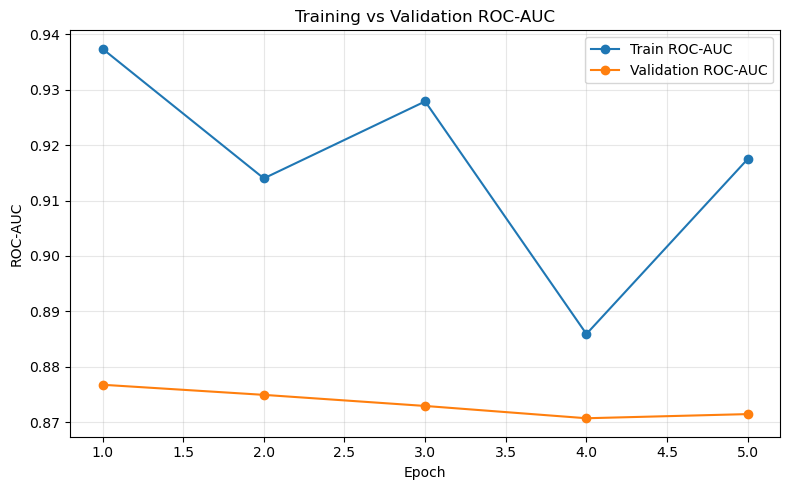

Validation Metrics: {'HitRate@1': 0.3, 'Recall@1': 0.3, 'NDCG@1': 0.3, 'HitRate@5': 0.41, 'Recall@5': 0.41, 'NDCG@5': 0.3600828475372232, 'HitRate@10': 0.53, 'Recall@10': 0.53, 'NDCG@10': 0.3985572237491223, 'HitRate@20': 0.79, 'Recall@20': 0.79, 'NDCG@20': 0.4662112522447309, 'MRR': 0.38454314377467924, 'n_users_evaluated': 100}
Test Metrics: {'HitRate@1': 0.32, 'Recall@1': 0.32, 'NDCG@1': 0.32, 'HitRate@5': 0.45, 'Recall@5': 0.45, 'NDCG@5': 0.38458524549403633, 'HitRate@10': 0.6, 'Recall@10': 0.6, 'NDCG@10': 0.4323529361311026, 'HitRate@20': 0.77, 'Recall@20': 0.77, 'NDCG@20': 0.4757747362339984, 'MRR': 0.4000295435180471, 'n_users_evaluated': 100}


In [15]:
import random
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------------------------
# Device
# ---------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Columns
# ---------------------------
USER_COL = "steamid"
GAME_COL = "appid"
TARGET = "owned"

# ---------------------------
# User & Game Features
# ---------------------------
USER_NUMERIC_FEATURES = [
    "total_games_owned","total_playtime_minutes","median_playtime_minutes",
    "unique_genres_played","friend_count",
    "user_playtime_group_Action","user_playtime_group_Adventure","user_playtime_group_RPG",
    "user_playtime_group_Casual","user_playtime_group_Indie","user_playtime_group_Racing",
    "user_playtime_group_Simulation","user_playtime_group_Strategy","user_playtime_group_Sports",
    "user_playtime_group_Violent","user_playtime_group_Adult","user_playtime_group_Non-gameplay_Tools",
    "user_playtime_group_Other"
]
USER_CATEGORICAL_FEATURES = ["country"]

GAME_NUMERIC_FEATURES = [
    "game_total_playtime_minutes","user_count",
    "release_date"
] + [f"game_emb_{i}" for i in range(32)]
GAME_CATEGORICAL_FEATURES = ["genres","developer","publisher","platforms"]

# ---------------------------
# File paths
# ---------------------------
files = {
    "train": r"D:\bachelor_project\ml\sets\train_sample.csv",
    "val": r"D:\bachelor_project\ml\sets\val_sample.csv",
    "test": r"D:\bachelor_project\ml\sets\test_sample.csv"
}

# ---------------------------
# Load CSVs
# ---------------------------
train_df = pd.read_csv(files["train"], sep=";", low_memory=False)
val_df   = pd.read_csv(files["val"], sep=";", low_memory=False)
test_df  = pd.read_csv(files["test"], sep=";", low_memory=False)

# ---------------------------
# Preprocessing
# ---------------------------
def preprocess_features(df, numeric_features, categorical_features):
    X_num = None
    if numeric_features:
        num_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        X_num = num_pipe.fit_transform(df[numeric_features])

    X_cat = None
    if categorical_features:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ])
        X_cat = cat_pipe.fit_transform(df[categorical_features]).toarray()

    if X_num is not None and X_cat is not None:
        X = np.hstack([X_num, X_cat])
    elif X_num is not None:
        X = X_num
    else:
        X = X_cat

    return torch.tensor(X, dtype=torch.float)

users = train_df[USER_COL].unique()
games = train_df[GAME_COL].unique()
user2idx = {u:i for i,u in enumerate(users)}
game2idx = {g:i for i,g in enumerate(games)}

user_features = train_df.drop_duplicates(USER_COL).set_index(USER_COL)
game_features = train_df.drop_duplicates(GAME_COL).set_index(GAME_COL)

user_x = preprocess_features(user_features, USER_NUMERIC_FEATURES, USER_CATEGORICAL_FEATURES).to(DEVICE)
game_x = preprocess_features(game_features, GAME_NUMERIC_FEATURES, GAME_CATEGORICAL_FEATURES).to(DEVICE)

user_in_dim = user_x.size(1)
game_in_dim = game_x.size(1)

# ---------------------------
# Neural Network Model
# ---------------------------
class MLPLinkPredictor(nn.Module):
    def __init__(self, user_dim, game_dim, hidden_channels):
        super().__init__()
        input_dim = user_dim + game_dim
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, user_x, game_x, pair_user, pair_game):
        user_feat = user_x[pair_user]
        game_feat = game_x[pair_game]
        x = torch.cat([user_feat, game_feat], dim=1)
        return self.model(x).squeeze()

# ---------------------------
# Prepare positive pairs for BPR
# ---------------------------
train_pos_df = train_df[train_df[TARGET]==1].copy()
user_pos_idx = {
    u: set([game2idx[g] for g in games])
    for u, games in train_pos_df.groupby(USER_COL)[GAME_COL].apply(list).items()
}

# ---------------------------
# Dynamic BPR sampling
# ---------------------------
def sample_bpr_batch(batch_users, user_pos_idx, num_games):
    u_list, pos_list, neg_list = [], [], []
    for u in batch_users:
        pos_item = random.choice(list(user_pos_idx[u]))
        while True:
            neg_item = random.randint(0, num_games-1)
            if neg_item not in user_pos_idx[u]:
                break
        u_list.append(user2idx[u])
        pos_list.append(pos_item)
        neg_list.append(neg_item)
    return (
        torch.tensor(u_list, dtype=torch.long, device=DEVICE),
        torch.tensor(pos_list, dtype=torch.long, device=DEVICE),
        torch.tensor(neg_list, dtype=torch.long, device=DEVICE)
    )

def bpr_loss(user_idx, pos_game_idx, neg_game_idx, model, user_x, game_x):
    scores_pos = model(user_x, game_x, user_idx, pos_game_idx)
    scores_neg = model(user_x, game_x, user_idx, neg_game_idx)
    return -torch.log(torch.sigmoid(scores_pos - scores_neg) + 1e-8).mean()

# ---------------------------
# Hyperparameters
# ---------------------------
batch_size = 512
num_epochs = 5
hidden_channels_list = [16,32]
learning_rates = [0.001,0.005]

best_val_score = -np.inf
best_model_state = None
best_config = None
best_train_roc = None
best_val_roc = None

# ---------------------------
# Training loop with BPR
# ---------------------------
user_list = list(user_pos_idx.keys())

for hidden_channels in hidden_channels_list:
    for lr in learning_rates:

        print(f"\n--- hidden_channels={hidden_channels}, lr={lr} ---")
        model = MLPLinkPredictor(user_in_dim, game_in_dim, hidden_channels).to(DEVICE)
        optimizer = Adam(model.parameters(), lr=lr)
        train_roc_list, val_roc_list = [], []

        for epoch in range(num_epochs):
            model.train()
            random.shuffle(user_list)
            epoch_loss = 0

            for i in range(0, len(user_list), batch_size):
                batch_users = user_list[i:i+batch_size]
                u, pos_g, neg_g = sample_bpr_batch(batch_users, user_pos_idx, len(games))

                optimizer.zero_grad()
                loss = bpr_loss(u, pos_g, neg_g, model, user_x, game_x)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(batch_users)

            epoch_loss /= len(user_list)

            # ---------------------------
            # Train ROC-AUC (sample)
            # ---------------------------
            with torch.no_grad():
                sample_users = random.sample(user_list, min(1000, len(user_list)))
                u, pos_g, neg_g = sample_bpr_batch(sample_users, user_pos_idx, len(games))
                scores = torch.cat([
                    model(user_x, game_x, u, pos_g),
                    model(user_x, game_x, u, neg_g)
                ])
                labels = torch.cat([
                    torch.ones(len(u), device=DEVICE),
                    torch.zeros(len(u), device=DEVICE)
                ])
                train_roc = roc_auc_score(labels.cpu().numpy(), scores.cpu().numpy())
                train_roc_list.append(train_roc)

                # Validation ROC-AUC
                val_user_idx = torch.tensor([user2idx.get(u,-1) for u in val_df[USER_COL]], dtype=torch.long).to(DEVICE)
                val_game_idx = torch.tensor([game2idx.get(g,-1) for g in val_df[GAME_COL]], dtype=torch.long).to(DEVICE)
                mask = (val_user_idx >=0) & (val_game_idx >=0)
                filtered_val_df = val_df[mask.cpu().numpy()]
                if len(filtered_val_df)>0:
                    val_scores = model(user_x, game_x, val_user_idx[mask], val_game_idx[mask]).cpu().numpy()
                    val_roc = roc_auc_score(filtered_val_df[TARGET], val_scores)
                    val_roc_list.append(val_roc)
                else:
                    val_roc_list.append(np.nan)

            print(f"Epoch {epoch} | Loss {epoch_loss:.4f} | Train ROC {train_roc:.4f} | Val ROC {val_roc_list[-1]:.4f}")

        avg_val_roc = np.nanmean(val_roc_list)
        if avg_val_roc > best_val_score:
            best_val_score = avg_val_roc
            best_model_state = model.state_dict()
            best_config = {"hidden_channels": hidden_channels, "lr": lr}
            best_train_roc = train_roc_list
            best_val_roc = val_roc_list

print("\nBest hyperparameters:", best_config)
plot_train_val_roc(best_train_roc, best_val_roc)

# ---------------------------
# Final evaluation
# ---------------------------
best_model = MLPLinkPredictor(user_in_dim, game_in_dim, best_config["hidden_channels"]).to(DEVICE)
best_model.load_state_dict(best_model_state)
best_model.eval()

def evaluate_df(df):
    user_idx = torch.tensor([user2idx.get(u,-1) for u in df[USER_COL]], dtype=torch.long).to(DEVICE)
    game_idx = torch.tensor([game2idx.get(g,-1) for g in df[GAME_COL]], dtype=torch.long).to(DEVICE)
    mask = (user_idx>=0) & (game_idx>=0)
    filtered_df = df[mask.cpu().numpy()]
    with torch.no_grad():
        scores = best_model(user_x, game_x, user_idx[mask], game_idx[mask]).cpu().numpy()
    return evaluate_ranking_df(filtered_df, scores)

val_metrics = evaluate_df(val_df)
test_metrics = evaluate_df(test_df)

print("Validation Metrics:", val_metrics)
print("Test Metrics:", test_metrics)

##### negative from train set


--- hidden_channels=16, lr=0.001 ---
Epoch 0 | Loss 0.4974 | Train ROC 0.9348 | Val ROC 0.6391
Epoch 1 | Loss 0.1992 | Train ROC 0.9786 | Val ROC 0.6847
Epoch 2 | Loss 0.0806 | Train ROC 0.9907 | Val ROC 0.7383
Epoch 3 | Loss 0.0353 | Train ROC 0.9959 | Val ROC 0.7549
Epoch 4 | Loss 0.0209 | Train ROC 0.9958 | Val ROC 0.7565

--- hidden_channels=16, lr=0.005 ---
Epoch 0 | Loss 0.2631 | Train ROC 0.9934 | Val ROC 0.7117
Epoch 1 | Loss 0.0174 | Train ROC 0.9966 | Val ROC 0.7515
Epoch 2 | Loss 0.0069 | Train ROC 0.9957 | Val ROC 0.7805
Epoch 3 | Loss 0.0049 | Train ROC 0.9974 | Val ROC 0.7494
Epoch 4 | Loss 0.0033 | Train ROC 0.9976 | Val ROC 0.7715

--- hidden_channels=32, lr=0.001 ---
Epoch 0 | Loss 0.4538 | Train ROC 0.9445 | Val ROC 0.6663
Epoch 1 | Loss 0.1126 | Train ROC 0.9919 | Val ROC 0.7362
Epoch 2 | Loss 0.0274 | Train ROC 0.9974 | Val ROC 0.7783
Epoch 3 | Loss 0.0136 | Train ROC 0.9980 | Val ROC 0.7802
Epoch 4 | Loss 0.0084 | Train ROC 0.9985 | Val ROC 0.7933

--- hidden_chan

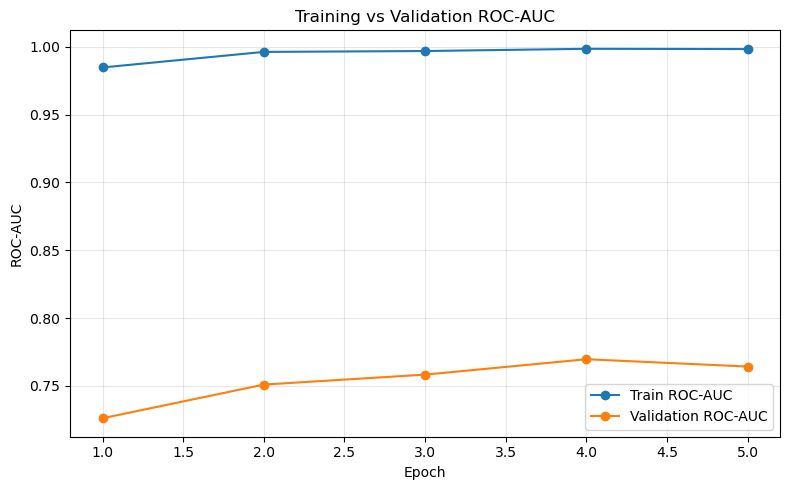

Validation Metrics: {'HitRate@1': 0.28, 'Recall@1': 0.28, 'NDCG@1': 0.28, 'HitRate@5': 0.4, 'Recall@5': 0.4, 'NDCG@5': 0.33933024858315874, 'HitRate@10': 0.53, 'Recall@10': 0.53, 'NDCG@10': 0.3810773393069454, 'HitRate@20': 0.64, 'Recall@20': 0.64, 'NDCG@20': 0.409250604941745, 'MRR': 0.35327729676301695, 'n_users_evaluated': 100}
Test Metrics: {'HitRate@1': 0.26, 'Recall@1': 0.26, 'NDCG@1': 0.26, 'HitRate@5': 0.39, 'Recall@5': 0.39, 'NDCG@5': 0.33364967393879597, 'HitRate@10': 0.5, 'Recall@10': 0.5, 'NDCG@10': 0.3692933609722042, 'HitRate@20': 0.61, 'Recall@20': 0.61, 'NDCG@20': 0.3973201522369741, 'MRR': 0.3463570297937947, 'n_users_evaluated': 100}


In [25]:
import random
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------------------------
# Device
# ---------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Columns
# ---------------------------
USER_COL = "steamid"
GAME_COL = "appid"
TARGET = "owned"

# ---------------------------
# User & Game Features
# ---------------------------
USER_NUMERIC_FEATURES = [
    "total_games_owned","total_playtime_minutes","median_playtime_minutes",
    "unique_genres_played","friend_count",
    "user_playtime_group_Action","user_playtime_group_Adventure","user_playtime_group_RPG",
    "user_playtime_group_Casual","user_playtime_group_Indie","user_playtime_group_Racing",
    "user_playtime_group_Simulation","user_playtime_group_Strategy","user_playtime_group_Sports",
    "user_playtime_group_Violent","user_playtime_group_Adult","user_playtime_group_Non-gameplay_Tools",
    "user_playtime_group_Other"
]
USER_CATEGORICAL_FEATURES = ["country"]

GAME_NUMERIC_FEATURES = [
    "game_total_playtime_minutes","user_count",
    "release_date"
] + [f"game_emb_{i}" for i in range(32)]
GAME_CATEGORICAL_FEATURES = ["genres","developer","publisher","platforms"]

# ---------------------------
# File paths
# ---------------------------
files = {
    "train": r"D:\bachelor_project\ml\sets\train_sample.csv",
    "val": r"D:\bachelor_project\ml\sets\val_sample.csv",
    "test": r"D:\bachelor_project\ml\sets\test_sample.csv"
}

# ---------------------------
# Load CSVs
# ---------------------------
train_df = pd.read_csv(files["train"], sep=";", low_memory=False)
val_df   = pd.read_csv(files["val"], sep=";", low_memory=False)
test_df  = pd.read_csv(files["test"], sep=";", low_memory=False)

# ---------------------------
# Preprocessing
# ---------------------------
def preprocess_features(df, numeric_features, categorical_features):
    X_num = None
    if numeric_features:
        num_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        X_num = num_pipe.fit_transform(df[numeric_features])

    X_cat = None
    if categorical_features:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ])
        X_cat = cat_pipe.fit_transform(df[categorical_features]).toarray()

    if X_num is not None and X_cat is not None:
        X = np.hstack([X_num, X_cat])
    elif X_num is not None:
        X = X_num
    else:
        X = X_cat

    return torch.tensor(X, dtype=torch.float)

users = train_df[USER_COL].unique()
games = train_df[GAME_COL].unique()
user2idx = {u:i for i,u in enumerate(users)}
game2idx = {g:i for i,g in enumerate(games)}

user_features = train_df.drop_duplicates(USER_COL).set_index(USER_COL)
game_features = train_df.drop_duplicates(GAME_COL).set_index(GAME_COL)

user_x = preprocess_features(user_features, USER_NUMERIC_FEATURES, USER_CATEGORICAL_FEATURES).to(DEVICE)
game_x = preprocess_features(game_features, GAME_NUMERIC_FEATURES, GAME_CATEGORICAL_FEATURES).to(DEVICE)

user_in_dim = user_x.size(1)
game_in_dim = game_x.size(1)

# ---------------------------
# Neural Network Model
# ---------------------------
class MLPLinkPredictor(nn.Module):
    def __init__(self, user_dim, game_dim, hidden_channels):
        super().__init__()
        input_dim = user_dim + game_dim
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, hidden_channels),
            nn.ReLU(),
            nn.Linear(hidden_channels, 1)
        )

    def forward(self, user_x, game_x, pair_user, pair_game):
        user_feat = user_x[pair_user]
        game_feat = game_x[pair_game]
        x = torch.cat([user_feat, game_feat], dim=1)
        return x.sum(dim=1) if False else self.model(x).squeeze()  # dot product or MLP output

# ---------------------------
# Prepare positives and negatives from CSV
# ---------------------------
train_pos_df = train_df[train_df[TARGET]==1].copy()
user_pos_dict = train_pos_df.groupby(USER_COL)[GAME_COL].apply(list).to_dict()

train_neg_df = train_df[train_df[TARGET]==0].copy()
user_neg_dict = train_neg_df.groupby(USER_COL)[GAME_COL].apply(list).to_dict()

# You can adjust this number: how many negatives per positive
num_negatives_per_positive = 10  # <-- change to 10 to use all negatives in CSV

u_all, pos_all, neg_all = [], [], []
for u, pos_list in user_pos_dict.items():
    neg_list = user_neg_dict.get(u, [])
    for pos_item in pos_list:
        sampled_negs = neg_list[:num_negatives_per_positive]
        for neg_item in sampled_negs:
            u_all.append(user2idx[u])
            pos_all.append(game2idx[pos_item])
            neg_all.append(game2idx[neg_item])

u_all = torch.tensor(u_all, dtype=torch.long, device=DEVICE)
pos_all = torch.tensor(pos_all, dtype=torch.long, device=DEVICE)
neg_all = torch.tensor(neg_all, dtype=torch.long, device=DEVICE)

# ---------------------------
# BPR loss
# ---------------------------
def bpr_loss(u_idx, pos_idx, neg_idx, model):
    scores_pos = model(user_x, game_x, u_idx, pos_idx)
    scores_neg = model(user_x, game_x, u_idx, neg_idx)
    return -torch.log(torch.sigmoid(scores_pos - scores_neg) + 1e-8).mean()

# ---------------------------
# Hyperparameters
# ---------------------------
batch_size = 512
num_epochs = 5
hidden_channels_list = [16,32]
learning_rates = [0.001,0.005]

best_val_score = -np.inf
best_model_state = None
best_config = None
best_train_roc = None
best_val_roc = None

# ---------------------------
# Training loop
# ---------------------------
for hidden_channels in hidden_channels_list:
    for lr in learning_rates:
        print(f"\n--- hidden_channels={hidden_channels}, lr={lr} ---")
        model = MLPLinkPredictor(user_in_dim, game_in_dim, hidden_channels).to(DEVICE)
        optimizer = Adam(model.parameters(), lr=lr)

        train_roc_list = []
        val_roc_list = []

        for epoch in range(num_epochs):
            model.train()
            perm = torch.randperm(len(u_all))
            u_shuff, pos_shuff, neg_shuff = u_all[perm], pos_all[perm], neg_all[perm]

            epoch_loss = 0
            for i in range(0, len(u_shuff), batch_size):
                batch_u = u_shuff[i:i+batch_size]
                batch_pos = pos_shuff[i:i+batch_size]
                batch_neg = neg_shuff[i:i+batch_size]

                optimizer.zero_grad()
                loss = bpr_loss(batch_u, batch_pos, batch_neg, model)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(batch_u)
            epoch_loss /= len(u_shuff)

            # Train ROC-AUC (sample)
            with torch.no_grad():
                sample_idx = np.random.choice(len(u_all), min(2000,len(u_all)), replace=False)
                scores = torch.cat([
                    model(user_x, game_x, u_all[sample_idx], pos_all[sample_idx]),
                    model(user_x, game_x, u_all[sample_idx], neg_all[sample_idx])
                ])
                labels = torch.cat([
                    torch.ones(len(sample_idx), device=DEVICE),
                    torch.zeros(len(sample_idx), device=DEVICE)
                ])
                train_roc = roc_auc_score(labels.cpu().numpy(), scores.cpu().numpy())
                train_roc_list.append(train_roc)

                # Validation ROC-AUC
                val_user_idx = torch.tensor([user2idx.get(u,-1) for u in val_df[USER_COL]], dtype=torch.long).to(DEVICE)
                val_game_idx = torch.tensor([game2idx.get(g,-1) for g in val_df[GAME_COL]], dtype=torch.long).to(DEVICE)
                mask = (val_user_idx>=0)&(val_game_idx>=0)
                filtered_val_df = val_df[mask.cpu().numpy()]
                if len(filtered_val_df)>0:
                    val_scores = model(user_x, game_x, val_user_idx[mask], val_game_idx[mask]).cpu().numpy()
                    val_roc = roc_auc_score(filtered_val_df[TARGET], val_scores)
                    val_roc_list.append(val_roc)
                else:
                    val_roc_list.append(np.nan)

            print(f"Epoch {epoch} | Loss {epoch_loss:.4f} | Train ROC {train_roc:.4f} | Val ROC {val_roc_list[-1]:.4f}")

        avg_val_roc = np.nanmean(val_roc_list)
        if avg_val_roc > best_val_score:
            best_val_score = avg_val_roc
            best_model_state = model.state_dict()
            best_config = {"hidden_channels": hidden_channels, "lr": lr}
            best_train_roc = train_roc_list
            best_val_roc = val_roc_list

print("\nBest hyperparameters:", best_config)

# ---------------------------
# Plot ROC curves
# ---------------------------
def plot_train_val_roc(train_roc, val_roc):
    epochs = range(1,len(train_roc)+1)
    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_roc, marker='o', label="Train ROC-AUC")
    plt.plot(epochs, val_roc, marker='o', label="Validation ROC-AUC")
    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Training vs Validation ROC-AUC")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_train_val_roc(best_train_roc, best_val_roc)

# ---------------------------
# Final evaluation
# ---------------------------
best_model = MLPLinkPredictor(user_in_dim, game_in_dim, best_config["hidden_channels"]).to(DEVICE)
best_model.load_state_dict(best_model_state)
best_model.eval()

def evaluate_df(df):
    user_idx = torch.tensor([user2idx.get(u,-1) for u in df[USER_COL]], dtype=torch.long).to(DEVICE)
    game_idx = torch.tensor([game2idx.get(g,-1) for g in df[GAME_COL]], dtype=torch.long).to(DEVICE)
    mask = (user_idx>=0)&(game_idx>=0)
    filtered_df = df[mask.cpu().numpy()]
    with torch.no_grad():
        scores = best_model(user_x, game_x, user_idx[mask], game_idx[mask]).cpu().numpy()
    return evaluate_ranking_df(filtered_df, scores)

val_metrics = evaluate_df(val_df)
test_metrics = evaluate_df(test_df)

print("Validation Metrics:", val_metrics)
print("Test Metrics:", test_metrics)

## Graph Neural Network

### GraphSAGE

##### random negative


--- hidden_channels=16, lr=0.001 ---
Epoch 0 | Loss: 0.6974 | Train ROC: 0.6826 | Val ROC: 0.6188
Epoch 1 | Loss: 0.6745 | Train ROC: 0.7734 | Val ROC: 0.7155
Epoch 2 | Loss: 0.6417 | Train ROC: 0.8216 | Val ROC: 0.7696
Epoch 3 | Loss: 0.6208 | Train ROC: 0.8857 | Val ROC: 0.7900
Epoch 4 | Loss: 0.5844 | Train ROC: 0.9285 | Val ROC: 0.7954

--- hidden_channels=16, lr=0.005 ---
Epoch 0 | Loss: 0.6906 | Train ROC: 0.9289 | Val ROC: 0.7989
Epoch 1 | Loss: 0.6107 | Train ROC: 0.9069 | Val ROC: 0.8176
Epoch 2 | Loss: 0.4731 | Train ROC: 0.9375 | Val ROC: 0.8156
Epoch 3 | Loss: 0.3382 | Train ROC: 0.9318 | Val ROC: 0.8098
Epoch 4 | Loss: 0.2661 | Train ROC: 0.8997 | Val ROC: 0.8018

--- hidden_channels=32, lr=0.001 ---
Epoch 0 | Loss: 0.7038 | Train ROC: 0.7201 | Val ROC: 0.6899
Epoch 1 | Loss: 0.6699 | Train ROC: 0.8057 | Val ROC: 0.7579
Epoch 2 | Loss: 0.6308 | Train ROC: 0.8373 | Val ROC: 0.7841
Epoch 3 | Loss: 0.5906 | Train ROC: 0.8758 | Val ROC: 0.7916
Epoch 4 | Loss: 0.5489 | Train R

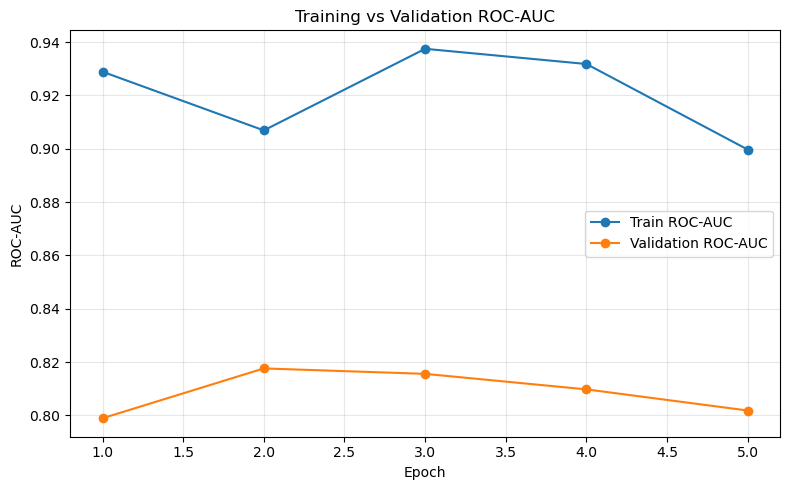

Validation Metrics: {'HitRate@1': 0.33, 'Recall@1': 0.33, 'NDCG@1': 0.33, 'HitRate@5': 0.43, 'Recall@5': 0.43, 'NDCG@5': 0.37688947911978965, 'HitRate@10': 0.55, 'Recall@10': 0.55, 'NDCG@10': 0.41308558400330625, 'HitRate@20': 0.71, 'Recall@20': 0.71, 'NDCG@20': 0.45379403993946155, 'MRR': 0.39357165267199967, 'n_users_evaluated': 100}
Test Metrics: {'HitRate@1': 0.32, 'Recall@1': 0.32, 'NDCG@1': 0.32, 'HitRate@5': 0.44, 'Recall@5': 0.44, 'NDCG@5': 0.37863701416389267, 'HitRate@10': 0.63, 'Recall@10': 0.63, 'NDCG@10': 0.44173276520907706, 'HitRate@20': 0.77, 'Recall@20': 0.77, 'NDCG@20': 0.4777953097762944, 'MRR': 0.4025201328740185, 'n_users_evaluated': 100}


In [17]:
import random
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, to_hetero
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------------------------
# Device
# ---------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Columns
# ---------------------------
USER_COL = "steamid"
GAME_COL = "appid"
TARGET = "owned"

# ---------------------------
# User features
# ---------------------------
USER_NUMERIC_FEATURES = [
    "total_games_owned",
    "total_playtime_minutes",
    "median_playtime_minutes",
    "unique_genres_played",
    "friend_count",
    "user_playtime_group_Action",
    "user_playtime_group_Adventure",
    "user_playtime_group_RPG",
    "user_playtime_group_Casual",
    "user_playtime_group_Indie",
    "user_playtime_group_Racing",
    "user_playtime_group_Simulation",
    "user_playtime_group_Strategy",
    "user_playtime_group_Sports",
    "user_playtime_group_Violent",
    "user_playtime_group_Adult",
    "user_playtime_group_Non-gameplay_Tools",
    "user_playtime_group_Other"
]

USER_CATEGORICAL_FEATURES = [
    "country"
]

# ---------------------------
# Game features
# ---------------------------
GAME_NUMERIC_FEATURES = [
    "game_total_playtime_minutes",
    "user_count",
    "release_date",
    "game_emb_0","game_emb_1","game_emb_2","game_emb_3","game_emb_4","game_emb_5","game_emb_6","game_emb_7",
    "game_emb_8","game_emb_9","game_emb_10","game_emb_11","game_emb_12","game_emb_13","game_emb_14","game_emb_15",
    "game_emb_16","game_emb_17","game_emb_18","game_emb_19","game_emb_20","game_emb_21","game_emb_22","game_emb_23",
    "game_emb_24","game_emb_25","game_emb_26","game_emb_27","game_emb_28","game_emb_29","game_emb_30","game_emb_31"
]

GAME_CATEGORICAL_FEATURES = [
    "genres",
    "developer",
    "publisher",
    "platforms"
]

# ---------------------------
# File paths
# ---------------------------
files = {
    "train": r"D:\bachelor_project\ml\sets\train_sample.csv",
    "val": r"D:\bachelor_project\ml\sets\val_sample.csv",
    "test": r"D:\bachelor_project\ml\sets\test_sample.csv"
}
friends_path = r"D:\bachelor_project\data_final\friends.csv"

# ---------------------------
# Load CSVs
# ---------------------------
train_df = pd.read_csv(files["train"], sep=";", low_memory=False)
val_df   = pd.read_csv(files["val"], sep=";", low_memory=False)
test_df  = pd.read_csv(files["test"], sep=";", low_memory=False)
friends_df = pd.read_csv(friends_path)

# ---------------------------
# Preprocessing
# ---------------------------
def preprocess_features(df, numeric_features, categorical_features):
    X_num = None
    if numeric_features:
        num_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        X_num = num_pipe.fit_transform(df[numeric_features])
    X_cat = None
    if categorical_features:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ])
        X_cat = cat_pipe.fit_transform(df[categorical_features]).toarray()
    if X_num is not None and X_cat is not None:
        X = np.hstack([X_num, X_cat])
    elif X_num is not None:
        X = X_num
    else:
        X = X_cat
    return torch.tensor(X, dtype=torch.float)

# ---------------------------
# Build Heterograph
# ---------------------------
def build_graph(df, friends_df):
    data = HeteroData()
    users = df[USER_COL].unique()
    games = df[GAME_COL].unique()
    user2idx = {u: i for i, u in enumerate(users)}
    game2idx = {g: i for i, g in enumerate(games)}

    # Node features
    user_features = df.drop_duplicates(USER_COL).set_index(USER_COL)
    data["user"].x = preprocess_features(user_features, USER_NUMERIC_FEATURES, USER_CATEGORICAL_FEATURES)

    game_features = df.drop_duplicates(GAME_COL).set_index(GAME_COL)
    data["game"].x = preprocess_features(game_features, GAME_NUMERIC_FEATURES, GAME_CATEGORICAL_FEATURES)

    # Positive edges
    pos_df = df[df[TARGET] == 1].copy()
    src = np.array([user2idx[u] for u in pos_df[USER_COL]])
    dst = np.array([game2idx[g] for g in pos_df[GAME_COL]])
    data["user","plays","game"].edge_index = torch.tensor(np.stack([src,dst],axis=0), dtype=torch.long)
    data["game","rev_plays","user"].edge_index = torch.tensor(np.stack([dst,src],axis=0), dtype=torch.long)

    # Friend edges
    valid_friends = friends_df[
        friends_df["user_steamid"].isin(user2idx) &
        friends_df["friend_steamid"].isin(user2idx)
    ]
    if len(valid_friends) > 0:
        u_src = valid_friends["user_steamid"].map(user2idx).to_numpy()
        u_dst = valid_friends["friend_steamid"].map(user2idx).to_numpy()
        edges = np.concatenate([np.stack([u_src, u_dst],axis=0), np.stack([u_dst,u_src],axis=0)], axis=1)
        data["user","friend","user"].edge_index = torch.tensor(edges, dtype=torch.long)

    return data, user2idx, game2idx

data, user2idx, game2idx = build_graph(train_df, friends_df)
data = data.to(DEVICE)

user_in_dim = data["user"].x.size(1)
game_in_dim = data["game"].x.size(1)

# ---------------------------
# GraphSAGE + Link Predictor
# ---------------------------
class GraphSAGENet(nn.Module):
    def __init__(self, hidden_channels, num_layers=2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv((-1,-1), hidden_channels))
        for _ in range(num_layers-1):
            self.convs.append(SAGEConv((-1,-1), hidden_channels))
    def forward(self, x_dict, edge_index_dict):
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict).relu()
        return x_dict

class LinkPredictor(nn.Module):
    def __init__(self, hidden_channels, metadata):
        super().__init__()
        self.gnn = to_hetero(GraphSAGENet(hidden_channels), metadata, aggr='sum')
    def forward(self, x_dict, edge_index_dict, pair_user, pair_game):
        x_dict = self.gnn(x_dict, edge_index_dict)
        user_emb = x_dict["user"][pair_user]
        game_emb = x_dict["game"][pair_game]
        return (user_emb * game_emb).sum(dim=-1)

# ---------------------------
# Prepare positive items dict for BPR
# ---------------------------
train_pos_df = train_df[train_df[TARGET]==1]
user_pos_idx = {
    u: set(game2idx[g] for g in games)
    for u, games in train_pos_df.groupby(USER_COL)[GAME_COL].apply(list).items()
}

# ---------------------------
# Dynamic BPR batch sampling
# ---------------------------
def sample_bpr_batch(batch_users, user_pos_idx, num_games):
    u_list, pos_list, neg_list = [], [], []
    for u in batch_users:
        pos_item = random.choice(list(user_pos_idx[u]))
        while True:
            neg_item = random.randint(0, num_games-1)
            if neg_item not in user_pos_idx[u]:
                break
        u_list.append(user2idx[u])
        pos_list.append(pos_item)
        neg_list.append(neg_item)
    return (
        torch.tensor(u_list, dtype=torch.long, device=DEVICE),
        torch.tensor(pos_list, dtype=torch.long, device=DEVICE),
        torch.tensor(neg_list, dtype=torch.long, device=DEVICE)
    )

def bpr_loss(user_idx, pos_game_idx, neg_game_idx, model, x_dict, edge_index_dict):
    scores_pos = model(x_dict, edge_index_dict, user_idx, pos_game_idx)
    scores_neg = model(x_dict, edge_index_dict, user_idx, neg_game_idx)
    return -torch.log(torch.sigmoid(scores_pos - scores_neg) + 1e-8).mean()

# ---------------------------
# Training parameters
# ---------------------------
batch_size = 512
num_epochs = 5
hidden_channels_list = [16,32]
learning_rates = [0.001,0.005]

best_val_score = -np.inf
best_model_state = None
best_config = None
best_train_roc = None
best_val_roc = None

# ---------------------------
# Training loop with dynamic BPR
# ---------------------------
for hidden_channels in hidden_channels_list:
    for lr in learning_rates:
        print(f"\n--- hidden_channels={hidden_channels}, lr={lr} ---")
        model = LinkPredictor(hidden_channels, data.metadata()).to(DEVICE)
        optimizer = Adam(model.parameters(), lr=lr)
        train_roc_list, val_roc_list = [], []

        user_list = list(user_pos_idx.keys())

        for epoch in range(num_epochs):
            model.train()
            random.shuffle(user_list)
            epoch_loss = 0

            for i in range(0, len(user_list), batch_size):
                batch_users = user_list[i:i+batch_size]
                u, pos_g, neg_g = sample_bpr_batch(batch_users, user_pos_idx, len(game2idx))

                optimizer.zero_grad()
                loss = bpr_loss(u, pos_g, neg_g, model, data.x_dict, data.edge_index_dict)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(batch_users)

            epoch_loss /= len(user_list)

            # ---------------------------
            # Train ROC (sample)
            # ---------------------------
            with torch.no_grad():
                sample_users = random.sample(user_list, min(1000,len(user_list)))
                u, pos_g, neg_g = sample_bpr_batch(sample_users, user_pos_idx, len(game2idx))
                scores = torch.cat([
                    model(data.x_dict, data.edge_index_dict, u, pos_g),
                    model(data.x_dict, data.edge_index_dict, u, neg_g)
                ])
                labels = torch.cat([torch.ones(len(u), device=DEVICE), torch.zeros(len(u), device=DEVICE)])
                train_roc = roc_auc_score(labels.cpu().numpy(), scores.cpu().numpy())
                train_roc_list.append(train_roc)

                # Validation ROC-AUC
                val_user_idx = torch.tensor([user2idx.get(u,-1) for u in val_df[USER_COL]], dtype=torch.long).to(DEVICE)
                val_game_idx = torch.tensor([game2idx.get(g,-1) for g in val_df[GAME_COL]], dtype=torch.long).to(DEVICE)
                mask = (val_user_idx >=0) & (val_game_idx >=0)
                filtered_val_df = val_df[mask.cpu().numpy()]
                if len(filtered_val_df)>0:
                    val_scores = model(data.x_dict, data.edge_index_dict, val_user_idx[mask], val_game_idx[mask]).cpu().numpy()
                    val_roc = roc_auc_score(filtered_val_df[TARGET], val_scores)
                    val_roc_list.append(val_roc)
                else:
                    val_roc_list.append(np.nan)

            print(f"Epoch {epoch} | Loss: {epoch_loss:.4f} | Train ROC: {train_roc:.4f} | Val ROC: {val_roc_list[-1]:.4f}")

        avg_val_roc = np.nanmean(val_roc_list)
        if avg_val_roc > best_val_score:
            best_val_score = avg_val_roc
            best_model_state = model.state_dict()
            best_config = {"hidden_channels": hidden_channels, "lr": lr}
            best_train_roc = train_roc_list
            best_val_roc = val_roc_list

print("\nBest hyperparameters:", best_config)
plot_train_val_roc(best_train_roc, best_val_roc)

# ---------------------------
# Evaluation on val/test
# ---------------------------
best_model = LinkPredictor(best_config["hidden_channels"], data.metadata()).to(DEVICE)
best_model.load_state_dict(best_model_state)
best_model.eval()

def evaluate_df(df):
    user_idx = torch.tensor([user2idx.get(u,-1) for u in df[USER_COL]], dtype=torch.long).to(DEVICE)
    game_idx = torch.tensor([game2idx.get(g,-1) for g in df[GAME_COL]], dtype=torch.long).to(DEVICE)
    mask = (user_idx >=0) & (game_idx>=0)
    filtered_df = df[mask.cpu().numpy()]
    with torch.no_grad():
        scores = best_model(data.x_dict, data.edge_index_dict, user_idx[mask], game_idx[mask]).cpu().numpy()
    return evaluate_ranking_df(filtered_df, scores)

val_metrics = evaluate_df(val_df)
test_metrics = evaluate_df(test_df)

print("Validation Metrics:", val_metrics)
print("Test Metrics:", test_metrics)

##### negative from train set


--- hidden_channels=16, lr=0.001 ---
Epoch 0 | Loss 0.4889 | Train ROC 0.9173 | Val ROC 0.7341
Epoch 1 | Loss 0.1925 | Train ROC 0.9611 | Val ROC 0.8003
Epoch 2 | Loss 0.0478 | Train ROC 0.9738 | Val ROC 0.8007
Epoch 3 | Loss 0.0170 | Train ROC 0.9781 | Val ROC 0.8044
Epoch 4 | Loss 0.0105 | Train ROC 0.9766 | Val ROC 0.8057

--- hidden_channels=16, lr=0.005 ---
Epoch 0 | Loss 0.2288 | Train ROC 0.9697 | Val ROC 0.8029
Epoch 1 | Loss 0.0114 | Train ROC 0.9810 | Val ROC 0.8076
Epoch 2 | Loss 0.0064 | Train ROC 0.9764 | Val ROC 0.8230
Epoch 3 | Loss 0.0034 | Train ROC 0.9863 | Val ROC 0.8169
Epoch 4 | Loss 0.0026 | Train ROC 0.9853 | Val ROC 0.8198

--- hidden_channels=32, lr=0.001 ---
Epoch 0 | Loss 0.4343 | Train ROC 0.9233 | Val ROC 0.7806
Epoch 1 | Loss 0.0943 | Train ROC 0.9630 | Val ROC 0.8009
Epoch 2 | Loss 0.0161 | Train ROC 0.9728 | Val ROC 0.8080
Epoch 3 | Loss 0.0085 | Train ROC 0.9749 | Val ROC 0.8073
Epoch 4 | Loss 0.0070 | Train ROC 0.9726 | Val ROC 0.8076

--- hidden_chan

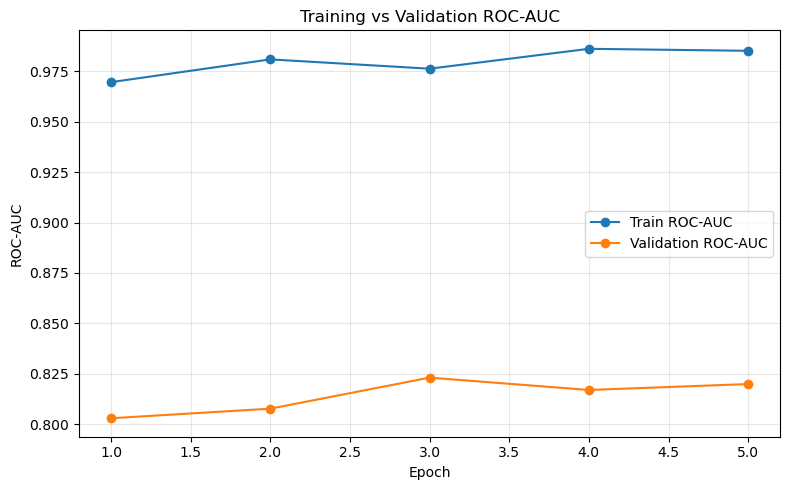

Validation Metrics: {'HitRate@1': 0.25, 'Recall@1': 0.25, 'NDCG@1': 0.25, 'HitRate@5': 0.4, 'Recall@5': 0.4, 'NDCG@5': 0.3258945430297509, 'HitRate@10': 0.51, 'Recall@10': 0.51, 'NDCG@10': 0.3619103911994507, 'HitRate@20': 0.74, 'Recall@20': 0.74, 'NDCG@20': 0.4197706838780141, 'MRR': 0.3403472019591776, 'n_users_evaluated': 100}
Test Metrics: {'HitRate@1': 0.3, 'Recall@1': 0.3, 'NDCG@1': 0.3, 'HitRate@5': 0.42, 'Recall@5': 0.42, 'NDCG@5': 0.35870877047725924, 'HitRate@10': 0.56, 'Recall@10': 0.56, 'NDCG@10': 0.404187638737858, 'HitRate@20': 0.73, 'Recall@20': 0.73, 'NDCG@20': 0.4470725183872078, 'MRR': 0.37835413382674843, 'n_users_evaluated': 100}


In [26]:
import random
import pandas as pd
import numpy as np
import torch
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import roc_auc_score
from torch_geometric.data import HeteroData
from torch_geometric.nn import SAGEConv, to_hetero
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ---------------------------
# Device
# ---------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Columns
# ---------------------------
USER_COL = "steamid"
GAME_COL = "appid"
TARGET = "owned"

# ---------------------------
# User & Game features
# ---------------------------
USER_NUMERIC_FEATURES = [
    "total_games_owned",
    "total_playtime_minutes",
    "median_playtime_minutes",
    "unique_genres_played",
    "friend_count"
]
USER_CATEGORICAL_FEATURES = ["country"]

GAME_NUMERIC_FEATURES = [
    "game_total_playtime_minutes",
    "user_count",
    "release_date",
    *["game_emb_{}".format(i) for i in range(32)]
]
GAME_CATEGORICAL_FEATURES = ["genres","developer","publisher","platforms"]

# ---------------------------
# File paths
# ---------------------------
files = {
    "train": r"D:\bachelor_project\ml\sets\train_sample.csv",
    "val": r"D:\bachelor_project\ml\sets\val_sample.csv",
    "test": r"D:\bachelor_project\ml\sets\test_sample.csv"
}
friends_path = r"D:\bachelor_project\data_final\friends.csv"

# ---------------------------
# Load CSVs
# ---------------------------
train_df = pd.read_csv(files["train"], sep=";", low_memory=False)
val_df   = pd.read_csv(files["val"], sep=";", low_memory=False)
test_df  = pd.read_csv(files["test"], sep=";", low_memory=False)
friends_df = pd.read_csv(friends_path)

# ---------------------------
# Preprocessing helper
# ---------------------------
def preprocess_features(df, numeric_features, categorical_features):
    X_num = None
    if numeric_features:
        num_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ])
        X_num = num_pipe.fit_transform(df[numeric_features])
    X_cat = None
    if categorical_features:
        cat_pipe = Pipeline([
            ("imputer", SimpleImputer(strategy="constant", fill_value="MISSING")),
            ("ohe", OneHotEncoder(handle_unknown="ignore"))
        ])
        X_cat = cat_pipe.fit_transform(df[categorical_features]).toarray()
    if X_num is not None and X_cat is not None:
        X = np.hstack([X_num, X_cat])
    elif X_num is not None:
        X = X_num
    else:
        X = X_cat
    return torch.tensor(X, dtype=torch.float)

# ---------------------------
# Build heterograph
# ---------------------------
def build_graph(df, friends_df):
    data = HeteroData()

    users = df[USER_COL].unique()
    games = df[GAME_COL].unique()
    user2idx = {u: i for i, u in enumerate(users)}
    game2idx = {g: i for i, g in enumerate(games)}

    # Node features
    user_features = df.drop_duplicates(USER_COL).set_index(USER_COL)
    data["user"].x = preprocess_features(
        user_features,
        USER_NUMERIC_FEATURES,
        USER_CATEGORICAL_FEATURES
    )

    game_features = df.drop_duplicates(GAME_COL).set_index(GAME_COL)
    data["game"].x = preprocess_features(
        game_features,
        GAME_NUMERIC_FEATURES,
        GAME_CATEGORICAL_FEATURES
    )

    # Positive user-game edges
    pos_df = df[df[TARGET]==1].copy()
    src = np.array([user2idx[u] for u in pos_df[USER_COL]])
    dst = np.array([game2idx[g] for g in pos_df[GAME_COL]])
    data["user","plays","game"].edge_index = torch.tensor(np.stack([src,dst],axis=0), dtype=torch.long)
    data["game","rev_plays","user"].edge_index = torch.tensor(np.stack([dst,src],axis=0), dtype=torch.long)

    # Friend edges
    valid_friends = friends_df[
        friends_df["user_steamid"].isin(user2idx) &
        friends_df["friend_steamid"].isin(user2idx)
    ]
    if len(valid_friends) > 0:
        u_src = valid_friends["user_steamid"].map(user2idx).to_numpy()
        u_dst = valid_friends["friend_steamid"].map(user2idx).to_numpy()
        edges = np.concatenate([
            np.stack([u_src,u_dst],axis=0),
            np.stack([u_dst,u_src],axis=0)
        ], axis=1)
        data["user","friend","user"].edge_index = torch.tensor(edges, dtype=torch.long)

    return data, user2idx, game2idx

data, user2idx, game2idx = build_graph(train_df, friends_df)
data = data.to(DEVICE)
user_in_dim = data["user"].x.size(1)
game_in_dim = data["game"].x.size(1)

# ---------------------------
# GraphSAGE + Link Predictor
# ---------------------------
class GraphSAGENet(nn.Module):
    def __init__(self, hidden_channels, num_layers=2):
        super().__init__()
        self.convs = nn.ModuleList()
        self.convs.append(SAGEConv((-1,-1), hidden_channels))
        for _ in range(num_layers-1):
            self.convs.append(SAGEConv((-1,-1), hidden_channels))

    def forward(self, x_dict, edge_index_dict):
        for conv in self.convs:
            x_dict = conv(x_dict, edge_index_dict).relu()
        return x_dict

class LinkPredictor(nn.Module):
    def __init__(self, hidden_channels, metadata):
        super().__init__()
        self.gnn = to_hetero(GraphSAGENet(hidden_channels), metadata, aggr='sum')
        self.lin = nn.Linear(hidden_channels*2,1)

    def forward(self, x_dict, edge_index_dict, pair_user, pair_game):
        x_dict = self.gnn(x_dict, edge_index_dict)
        user_emb = x_dict["user"][pair_user]
        game_emb = x_dict["game"][pair_game]
        return (user_emb * game_emb).sum(dim=-1)  # BPR uses dot product

# ---------------------------
# Prepare positives and negatives from CSV
# ---------------------------
train_pos_df = train_df[train_df[TARGET]==1].copy()
user_pos = train_pos_df.groupby(USER_COL)[GAME_COL].apply(list).to_dict()

# Collect negatives from CSV: each positive has 10 negatives
negatives_dict = train_df[train_df[TARGET]==0].groupby(USER_COL)[GAME_COL].apply(list).to_dict()

# Build training arrays
u_all, pos_all, neg_all = [],[],[]
num_negatives_per_positive = 10  # <-- change to 10 to use all negatives from CSV

for u, pos_list in user_pos.items():
    neg_list = negatives_dict.get(u, [])
    for pos_item in pos_list:
        # take up to `num_negatives_per_positive` negatives for this positive
        sampled_negs = neg_list[:num_negatives_per_positive]
        for neg_item in sampled_negs:
            u_all.append(user2idx[u])
            pos_all.append(game2idx[pos_item])
            neg_all.append(game2idx[neg_item])

u_all = torch.tensor(u_all, dtype=torch.long, device=DEVICE)
pos_all = torch.tensor(pos_all, dtype=torch.long, device=DEVICE)
neg_all = torch.tensor(neg_all, dtype=torch.long, device=DEVICE)

# ---------------------------
# BPR loss
# ---------------------------
def bpr_loss(u_idx, pos_idx, neg_idx, model):
    scores_pos = model(data.x_dict, data.edge_index_dict, u_idx, pos_idx)
    scores_neg = model(data.x_dict, data.edge_index_dict, u_idx, neg_idx)
    return -torch.log(torch.sigmoid(scores_pos - scores_neg) + 1e-8).mean()

# ---------------------------
# Training loop
# ---------------------------
hidden_channels_list = [16,32]
learning_rates = [0.001,0.005]
num_epochs = 5
batch_size = 1024

best_val_score = -np.inf
best_model_state = None
best_config = None
best_train_roc = None
best_val_roc = None

for hidden_channels in hidden_channels_list:
    for lr in learning_rates:
        print(f"\n--- hidden_channels={hidden_channels}, lr={lr} ---")
        model = LinkPredictor(hidden_channels, data.metadata()).to(DEVICE)
        optimizer = Adam(model.parameters(), lr=lr)

        train_roc_list = []
        val_roc_list = []

        for epoch in range(num_epochs):
            model.train()
            # Shuffle training data
            perm = torch.randperm(len(u_all))
            u_all_shuff = u_all[perm]
            pos_all_shuff = pos_all[perm]
            neg_all_shuff = neg_all[perm]

            epoch_loss = 0
            for i in range(0, len(u_all_shuff), batch_size):
                batch_u = u_all_shuff[i:i+batch_size]
                batch_pos = pos_all_shuff[i:i+batch_size]
                batch_neg = neg_all_shuff[i:i+batch_size]

                optimizer.zero_grad()
                loss = bpr_loss(batch_u, batch_pos, batch_neg, model)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(batch_u)
            epoch_loss /= len(u_all_shuff)

            # Training ROC on small sample
            with torch.no_grad():
                sample_idx = np.random.choice(len(u_all), min(2000,len(u_all)), replace=False)
                sample_u = u_all[sample_idx]
                sample_pos = pos_all[sample_idx]
                sample_neg = neg_all[sample_idx]
                scores = torch.cat([
                    model(data.x_dict, data.edge_index_dict, sample_u, sample_pos),
                    model(data.x_dict, data.edge_index_dict, sample_u, sample_neg)
                ])
                labels = torch.cat([
                    torch.ones(len(sample_u), device=DEVICE),
                    torch.zeros(len(sample_u), device=DEVICE)
                ])
                train_roc = roc_auc_score(labels.cpu().numpy(), scores.cpu().numpy())
                train_roc_list.append(train_roc)

                # Validation
                val_user_idx = torch.tensor([user2idx.get(u,-1) for u in val_df[USER_COL]], dtype=torch.long, device=DEVICE)
                val_game_idx = torch.tensor([game2idx.get(g,-1) for g in val_df[GAME_COL]], dtype=torch.long, device=DEVICE)
                mask = (val_user_idx >=0) & (val_game_idx >=0)
                filtered_val_df = val_df[mask.cpu().numpy() if mask.is_cuda else mask.numpy()]
                if len(filtered_val_df)>0:
                    val_scores = model(data.x_dict, data.edge_index_dict, val_user_idx[mask], val_game_idx[mask]).cpu().numpy()
                    val_roc = roc_auc_score(filtered_val_df[TARGET], val_scores)
                    val_roc_list.append(val_roc)
                else:
                    val_roc_list.append(np.nan)

            print(f"Epoch {epoch} | Loss {epoch_loss:.4f} | Train ROC {train_roc:.4f} | Val ROC {val_roc_list[-1]:.4f}")

        avg_val_roc = np.nanmean(val_roc_list)
        if avg_val_roc > best_val_score:
            best_val_score = avg_val_roc
            best_model_state = model.state_dict()
            best_config = {"hidden_channels": hidden_channels, "lr": lr}
            best_train_roc = train_roc_list
            best_val_roc = val_roc_list

print("\nBest hyperparameters:", best_config)

# ---------------------------
# Plot ROC curves
# ---------------------------
def plot_train_val_roc(train_roc, val_roc):
    epochs = range(1,len(train_roc)+1)
    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_roc, marker='o', label="Train ROC-AUC")
    plt.plot(epochs, val_roc, marker='o', label="Validation ROC-AUC")
    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Training vs Validation ROC-AUC")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_train_val_roc(best_train_roc, best_val_roc)

# ---------------------------
# Evaluate on validation and test
# ---------------------------
best_model = LinkPredictor(best_config["hidden_channels"], data.metadata()).to(DEVICE)
best_model.load_state_dict(best_model_state)
best_model.eval()

def evaluate_df(df):
    user_idx = torch.tensor([user2idx.get(u,-1) for u in df[USER_COL]], dtype=torch.long, device=DEVICE)
    game_idx = torch.tensor([game2idx.get(g,-1) for g in df[GAME_COL]], dtype=torch.long, device=DEVICE)
    mask = (user_idx >= 0) & (game_idx >= 0)
    filtered_df = df[mask.cpu().numpy() if mask.is_cuda else mask.numpy()]
    with torch.no_grad():
        scores = model(data.x_dict, data.edge_index_dict, user_idx[mask], game_idx[mask]).cpu().numpy()
    return evaluate_ranking_df(filtered_df, scores)

val_metrics = evaluate_df(val_df)
test_metrics = evaluate_df(test_df)

print("Validation Metrics:", val_metrics)
print("Test Metrics:", test_metrics)

### LightGCN


--- hidden_channels=16, lr=0.001 ---
Epoch 0 | Loss: 0.6929 | Train ROC: 0.8156 | Val ROC: 0.6050
Epoch 1 | Loss: 0.6928 | Train ROC: 0.8558 | Val ROC: 0.6292
Epoch 2 | Loss: 0.6927 | Train ROC: 0.8699 | Val ROC: 0.6517
Epoch 3 | Loss: 0.6925 | Train ROC: 0.8248 | Val ROC: 0.6714
Epoch 4 | Loss: 0.6923 | Train ROC: 0.8802 | Val ROC: 0.6887

--- hidden_channels=16, lr=0.005 ---
Epoch 0 | Loss: 0.6929 | Train ROC: 0.8538 | Val ROC: 0.6404
Epoch 1 | Loss: 0.6916 | Train ROC: 0.8373 | Val ROC: 0.7137
Epoch 2 | Loss: 0.6897 | Train ROC: 0.7362 | Val ROC: 0.7476
Epoch 3 | Loss: 0.6862 | Train ROC: 0.7831 | Val ROC: 0.7640
Epoch 4 | Loss: 0.6816 | Train ROC: 0.8105 | Val ROC: 0.7701

--- hidden_channels=32, lr=0.001 ---
Epoch 0 | Loss: 0.6927 | Train ROC: 0.8729 | Val ROC: 0.6107
Epoch 1 | Loss: 0.6925 | Train ROC: 0.8516 | Val ROC: 0.6397
Epoch 2 | Loss: 0.6922 | Train ROC: 0.8582 | Val ROC: 0.6699
Epoch 3 | Loss: 0.6917 | Train ROC: 0.8318 | Val ROC: 0.7012
Epoch 4 | Loss: 0.6915 | Train R

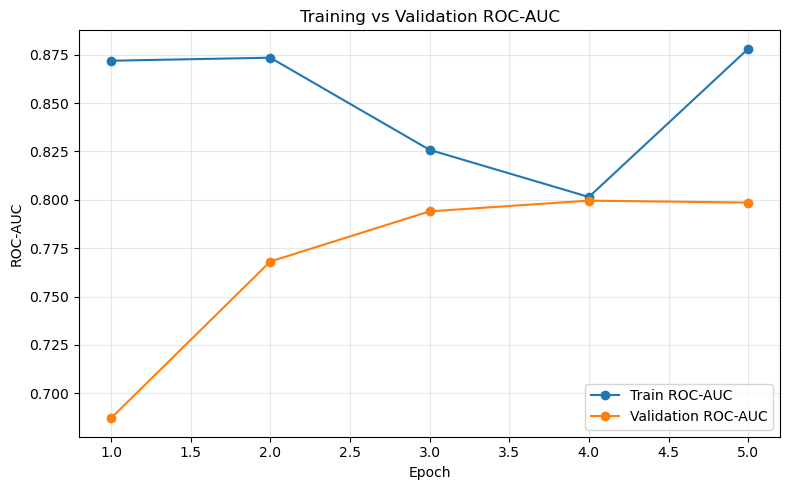

Validation Metrics: {'HitRate@1': 0.34, 'Recall@1': 0.34, 'NDCG@1': 0.34, 'HitRate@5': 0.47, 'Recall@5': 0.47, 'NDCG@5': 0.3993715383536029, 'HitRate@10': 0.63, 'Recall@10': 0.63, 'NDCG@10': 0.4496830729720709, 'HitRate@20': 0.77, 'Recall@20': 0.77, 'NDCG@20': 0.4849086114406312, 'MRR': 0.41322759406814463, 'n_users_evaluated': 100}
Test Metrics: {'HitRate@1': 0.29, 'Recall@1': 0.29, 'NDCG@1': 0.29, 'HitRate@5': 0.43, 'Recall@5': 0.43, 'NDCG@5': 0.36926573705524446, 'HitRate@10': 0.56, 'Recall@10': 0.56, 'NDCG@10': 0.41030865436630193, 'HitRate@20': 0.72, 'Recall@20': 0.72, 'NDCG@20': 0.45075360699896927, 'MRR': 0.3855921873525414, 'n_users_evaluated': 100}


In [23]:
import random
import pandas as pd
import numpy as np
import torch
from sklearn.metrics import roc_auc_score
import torch.nn as nn
from torch.optim import Adam
import matplotlib.pyplot as plt
from torch_geometric.nn import LGConv

# ---------------------------
# Reproducibility
# ---------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ---------------------------
# Device
# ---------------------------
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---------------------------
# Columns
# ---------------------------
USER_COL = "steamid"
GAME_COL = "appid"
TARGET = "owned"

# ---------------------------
# File paths
# ---------------------------
files = {
    "train": r"D:\bachelor_project\ml\sets\train_sample.csv",
    "val": r"D:\bachelor_project\ml\sets\val_sample.csv",
    "test": r"D:\bachelor_project\ml\sets\test_sample.csv"
}

# ---------------------------
# Load CSVs
# ---------------------------
train_df = pd.read_csv(files["train"], sep=";", low_memory=False)
val_df   = pd.read_csv(files["val"], sep=";", low_memory=False)
test_df  = pd.read_csv(files["test"], sep=";", low_memory=False)

# ---------------------------
# Build ID mappings
# ---------------------------
users = train_df[USER_COL].unique()
games = train_df[GAME_COL].unique()

user2idx = {u: i for i, u in enumerate(users)}
game2idx = {g: i for i, g in enumerate(games)}

num_users = len(user2idx)
num_games = len(game2idx)

# ---------------------------
# Build LightGCN edge index (positive edges only)
# ---------------------------
train_pos_df = train_df[train_df[TARGET] == 1].copy()
src = np.array([user2idx[u] for u in train_pos_df[USER_COL]])
dst = np.array([game2idx[g] for g in train_pos_df[GAME_COL]]) + num_users

edge_index = torch.tensor(
    np.vstack([np.concatenate([src, dst]), np.concatenate([dst, src])]),
    dtype=torch.long
).to(DEVICE)

# ---------------------------
# Map positives and negatives for each user
# ---------------------------
user_pos_idx = {
    u: list(games)
    for u, games in train_pos_df.groupby(USER_COL)[GAME_COL].apply(list).items()
}

train_neg_df = train_df[train_df[TARGET] == 0].copy()
user_neg_idx = {
    u: list(games)
    for u, games in train_neg_df.groupby(USER_COL)[GAME_COL].apply(list).items()
}

# ---------------------------
# LightGCN Model
# ---------------------------
class LightGCN(nn.Module):
    def __init__(self, num_users, num_games, embedding_dim, num_layers=3):
        super().__init__()
        self.num_layers = num_layers
        self.user_embedding = nn.Embedding(num_users, embedding_dim)
        self.game_embedding = nn.Embedding(num_games, embedding_dim)
        self.convs = nn.ModuleList([LGConv() for _ in range(num_layers)])
        nn.init.xavier_uniform_(self.user_embedding.weight)
        nn.init.xavier_uniform_(self.game_embedding.weight)

    def forward(self, edge_index):
        x = torch.cat([self.user_embedding.weight, self.game_embedding.weight], dim=0)
        all_embeddings = [x]
        for conv in self.convs:
            x = conv(x, edge_index)
            all_embeddings.append(x)
        x = torch.stack(all_embeddings, dim=0).mean(dim=0)
        user_emb, game_emb = torch.split(x, [num_users, num_games])
        return user_emb, game_emb

class LinkPredictor(nn.Module):
    def __init__(self, num_users, num_games, hidden_channels, edge_index):
        super().__init__()
        self.edge_index = edge_index
        self.gnn = LightGCN(num_users, num_games, hidden_channels)

    def forward(self, user_idx, game_idx):
        user_emb, game_emb = self.gnn(self.edge_index)
        u = user_emb[user_idx]
        g = game_emb[game_idx]
        return (u * g).sum(dim=-1)

# ---------------------------
# Dynamic BPR batch sampling from CSV negatives
# ---------------------------
num_negatives_per_positive = 10  # <-- adjust this number (2 for testing, 10 for full)
batch_size = 512

def sample_bpr_batch_from_csv(batch_users):
    u_list, pos_list, neg_list = [], [], []
    for u in batch_users:
        pos_items = user_pos_idx[u]
        neg_items = user_neg_idx.get(u, [])
        sampled_negs = random.sample(neg_items, min(num_negatives_per_positive, len(neg_items)))
        for pos_item in pos_items:
            for neg_item in sampled_negs:
                u_list.append(user2idx[u])
                pos_list.append(game2idx[pos_item])
                neg_list.append(game2idx[neg_item])
    return (
        torch.tensor(u_list, dtype=torch.long, device=DEVICE),
        torch.tensor(pos_list, dtype=torch.long, device=DEVICE),
        torch.tensor(neg_list, dtype=torch.long, device=DEVICE)
    )

def bpr_loss(user_idx, pos_game_idx, neg_game_idx, model):
    scores_pos = model(user_idx, pos_game_idx)
    scores_neg = model(user_idx, neg_game_idx)
    return -torch.log(torch.sigmoid(scores_pos - scores_neg) + 1e-8).mean()

# ---------------------------
# Hyperparameters
# ---------------------------
num_epochs = 5
learning_rates = [0.001, 0.005]
hidden_channels_list = [16, 32]

best_val_score = -np.inf
best_model_state = None
best_config = None
best_train_roc = None
best_val_roc = None

# ---------------------------
# Training loop with BPR from CSV
# ---------------------------
user_list = list(user_pos_idx.keys())

for hidden_channels in hidden_channels_list:
    for lr in learning_rates:
        print(f"\n--- hidden_channels={hidden_channels}, lr={lr} ---")
        model = LinkPredictor(num_users, num_games, hidden_channels, edge_index).to(DEVICE)
        optimizer = Adam(model.parameters(), lr=lr)

        train_roc_list, val_roc_list = [], []

        for epoch in range(num_epochs):
            model.train()
            random.shuffle(user_list)
            epoch_loss = 0

            for i in range(0, len(user_list), batch_size):
                batch_users = user_list[i:i+batch_size]
                u, pos_g, neg_g = sample_bpr_batch_from_csv(batch_users)

                optimizer.zero_grad()
                loss = bpr_loss(u, pos_g, neg_g, model)
                loss.backward()
                optimizer.step()
                epoch_loss += loss.item() * len(batch_users)

            epoch_loss /= len(user_list)

            # Training ROC sample
            with torch.no_grad():
                sample_users = random.sample(user_list, min(1000,len(user_list)))
                u, pos_g, neg_g = sample_bpr_batch_from_csv(sample_users)
                scores = torch.cat([model(u, pos_g), model(u, neg_g)])
                labels = torch.cat([torch.ones(len(u), device=DEVICE), torch.zeros(len(u), device=DEVICE)])
                train_roc = roc_auc_score(labels.cpu().numpy(), scores.cpu().numpy())
                train_roc_list.append(train_roc)

                # Validation ROC
                val_user_idx = torch.tensor([user2idx.get(u,-1) for u in val_df[USER_COL]], dtype=torch.long).to(DEVICE)
                val_game_idx = torch.tensor([game2idx.get(g,-1) for g in val_df[GAME_COL]], dtype=torch.long).to(DEVICE)
                mask = (val_user_idx >= 0) & (val_game_idx >= 0)
                filtered_val_df = val_df[mask.cpu().numpy()]
                if len(filtered_val_df) > 0:
                    val_scores = model(val_user_idx[mask], val_game_idx[mask]).cpu().numpy()
                    val_roc = roc_auc_score(filtered_val_df[TARGET], val_scores)
                    val_roc_list.append(val_roc)
                else:
                    val_roc_list.append(np.nan)

            print(f"Epoch {epoch} | Loss: {epoch_loss:.4f} | Train ROC: {train_roc:.4f} | Val ROC: {val_roc_list[-1]:.4f}")

        avg_val_roc = np.nanmean(val_roc_list)
        if avg_val_roc > best_val_score:
            best_val_score = avg_val_roc
            best_model_state = model.state_dict()
            best_config = {"hidden_channels": hidden_channels, "lr": lr}
            best_train_roc = train_roc_list
            best_val_roc = val_roc_list

print("\nBest hyperparameters:", best_config)

# ---------------------------
# Plot ROC curves
# ---------------------------
def plot_train_val_roc(train_roc, val_roc):
    epochs = range(1,len(train_roc)+1)
    plt.figure(figsize=(8,5))
    plt.plot(epochs, train_roc, marker='o', label="Train ROC-AUC")
    plt.plot(epochs, val_roc, marker='o', label="Validation ROC-AUC")
    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Training vs Validation ROC-AUC")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_train_val_roc(best_train_roc, best_val_roc)

# ---------------------------
# Final evaluation
# ---------------------------
best_model = LinkPredictor(num_users, num_games, best_config["hidden_channels"], edge_index).to(DEVICE)
best_model.load_state_dict(best_model_state)
best_model.eval()

def evaluate_df(df):
    user_idx = torch.tensor([user2idx.get(u,-1) for u in df[USER_COL]], dtype=torch.long).to(DEVICE)
    game_idx = torch.tensor([game2idx.get(g,-1) for g in df[GAME_COL]], dtype=torch.long).to(DEVICE)
    mask = (user_idx >= 0) & (game_idx >= 0)
    filtered_df = df[mask.cpu().numpy()]
    with torch.no_grad():
        scores = best_model(user_idx[mask], game_idx[mask]).cpu().numpy()
    return evaluate_ranking_df(filtered_df, scores)

val_metrics = evaluate_df(val_df)
test_metrics = evaluate_df(test_df)

print("Validation Metrics:", val_metrics)
print("Test Metrics:", test_metrics)